# Building a Physics-Stratified Seismic Phase Picker Benchmark — Step 1

**Research question:** Can any existing pretrained PhaseNet model already serve as a competent *global* phase picker across all distance regimes, or is retraining on a union of datasets necessary?

**Approach:** Survey pretrained models and datasets in SeisBench, characterise their physics coverage (magnitude, depth, distance), then build a stratified benchmark that enables fair cross-domain evaluation — including teleseismic distances and fine-grained geographic diversity.

**Author:** Akash Kharita, University of Washington  
**Date:** May 2026

---

## What this notebook produces

`benchmark_manifest.csv` — a physics-stratified benchmark with the following properties:

| Property | Value |
|----------|-------|
| Datasets | STEAD, CEED, INSTANCE, PNW, TXED, ETHZ, AQ2009GM, MLAAPDE, OBST2024, VCSEIS, CWA |
| Distance strata | local <150 km · regional 150–1500 km · teleseismic >1500 km |
| Depth strata | 0–15 · 15–70 · 70–300 · >300 km |
| Magnitude strata | M<3 · M3–6 · M>6 |
| Physics bins | 3 × 4 × 3 = 36 bins · target 3,000 traces/bin · cap 1,000 traces/dataset/bin |
| Specialty flat samples | OBS (OBST2024) · Volcanic (VCSEIS) · Strong-motion (CWA) |
| Geographic labelling | `geo_region` column — fine-grained regions from source lat/lon (e.g. Northern California, Southern California, Pacific Northwest, Italy / Apennines, Switzerland / Alpine) |
| Teleseismic source | MLAAPDE (supersedes NEIC; sharded monthly, July 2013 – Oct 2014) |

**Dataset decisions:**
- SCEDC → replaced by **CEED** (better-quality California dataset, advisor recommendation)
- **Iquique** removed (data quality issues, small size — advisor recommendation)
- LenDB, NEIC, GEOFON excluded (P-only / <1% S picks / semi-automatic labels)
- Label errors flagged by Aguilar et al. (2024) removed from STEAD, INSTANCE, PNW, TXED, ETHZ

---

## Table of Contents

1. [1.1 Model Inventory](#1.1)
2. [1.2 Dataset Inventory](#1.2)
3. [1.3 Column Harmonization](#1.3)
4. [1.4 Physics Parameter Distributions](#1.4)
5. [1.4b S-P Time Distributions](#1.4b-sp)
6. [1.4c Label Quality Filtering](#1.4b)
7. [1.5 Benchmark Construction](#1.5)
8. [1.6 Benchmark Summary & Visualisation](#1.6)


In [41]:
import pandas as pd
import numpy as np
from pathlib import Path
import json

# SeisBench cache location
CACHE = Path("/data/wsd04/ak287/.seisbench/datasets")
assert CACHE.exists(), f"SeisBench cache not found at {CACHE}"

# ── Shared helpers (used throughout all sections) ─────────────────────────────

def get_meta_files(name):
    """Return all complete metadata CSVs for a dataset.
    Handles all sharding patterns:
      metadata.csv          standard
      metadata_YYYYMM.csv   MLAAPDE monthly
      metadata_*.csv        VCSEIS, CWA named shards
      metadata[0-9]*.csv    AQ2009GM numeric shards
    """
    ds_dir = CACHE / name
    if not ds_dir.exists():
        return []
    single = ds_dir / 'metadata.csv'
    if single.exists():
        return [single]
    return sorted([
        f for f in ds_dir.glob('metadata*.csv')
        if not f.name.endswith('.partial')
    ])

def get_any_meta_file(name):
    """Return the first available metadata CSV for a dataset."""
    files = get_meta_files(name)
    return files[0] if files else None

def haversine_km(lat1, lon1, lat2, lon2):
    """Vectorized Haversine distance in km."""
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))


<a id='1.1'></a>
## 1.1 Model Inventory

List all pretrained weights available for PhaseNet (16 weights) and EQTransformer (13 weights) in SeisBench. PhaseNet is the primary model family for this study — it takes a fixed 3,000-sample (30 s at 100 Hz) three-component waveform and outputs continuous P, S, and noise probability curves.

These weights are what we will evaluate on the benchmark built in Section 1.5. The tiering below determines which weights are priority candidates versus regional baselines.


In [42]:
import seisbench.models as sbm

print("PhaseNet pretrained weights:")
for w in sbm.PhaseNet.list_pretrained():
    print(f"  {w}")

print("\nEQTransformer pretrained weights:")
for w in sbm.EQTransformer.list_pretrained():
    print(f"  {w}")

PhaseNet pretrained weights:
  diting
  ethz
  geofon
  instance
  iquique
  jma
  jma_wc
  lendb
  neic
  obs
  original
  phasenet_sn
  pisdl
  scedc
  stead
  volpick

EQTransformer pretrained weights:
  ethz
  geofon
  instance
  iquique
  lendb
  neic
  obs
  original
  original_nonconservative
  scedc
  stead
  volpick


In [43]:
# Detailed metadata for each PhaseNet weight
pn_details = sbm.PhaseNet.list_pretrained(details=True)
for name, desc in pn_details.items():
    print(f"\n{'='*60}")
    print(f"{name}")
    print(desc[:200] + '...' if len(desc) > 200 else desc)


diting
Model trained on the DiTing dataset, a large-scale Chinese seismic benchmark dataset.
For models fine-tuned on individual regions in China, please see: https://github.com/JUNZHU-SEIS/USTC-Pickers
If y...

ethz
Model trained on ETHZ for 100 epochs with a learning rate of 0.01.
Threshold selected for optimal F1 score on in-domain evaluation. Depending on the target region, the thresholds might need to be adju...

geofon
Model trained on GEOFON for 100 epochs with a learning rate of 0.001.
Threshold selected for optimal F1 score on in-domain evaluation. Depending on the target region, the thresholds might need to be a...

instance
Model trained on INSTANCE for 100 epochs with a learning rate of 0.001.
Threshold selected for optimal F1 score on in-domain evaluation. Depending on the target region, the thresholds might need to be...

iquique
Model trained on Iquique for 100 epochs with a learning rate of 0.01.
Threshold selected for optimal F1 score on in-domain evaluation. Dependin

### Model Tiering

Based on training data scope and geographic diversity — **revised with rationale from Münchmeyer et al. (2022)**:

| Tier | Weights | Rationale |
|------|---------|----------|
| **A — Generalist candidates** | `stead`, `instance`, `neic` | Large, diverse training sets with proven cross-domain transfer (Münchmeyer et al., 2022) |
| **B — Specialty / large-regional** | `diting`, `obs`, `volpick`, `pisdl`, `phasenet_sn`, `jma`, `jma_wc` | Unique station/event types *or* large but geographically homogeneous |
| **C — Regional baselines + historical** | `scedc`, `ethz`, `iquique`, `lendb`, `original` | Regional specialists and the original PhaseNet used as reference |
| **D — Teleseismic baselines** | `geofon`, `neic` | Primarily teleseismic distance range |

> **Note on `original`:** Trained on ~780K Northern California waveforms (Zhu & Beroza, 2018) — geographically narrow; treated as a historical baseline rather than a generalist.

> **Note on `diting`:** Largest single-dataset model (~2.7M events) but exclusively Chinese seismicity. Size alone does not guarantee diversity; Münchmeyer et al. (2022) show that *diversity* (multi-region, complex tectonic settings) is the key driver of cross-domain transfer. Moved to Tier B.

> **Note on `neic`:** The `neic` *model weight* is trained on the original NEIC catalog and is still evaluated here (Tier A+D). However, the NEIC *dataset* in SeisBench has been superseded by MLAAPDE (see Section 1.5). The benchmark *traces* at teleseismic distances come from MLAAPDE, not NEIC. Münchmeyer et al. (2022) also note that NEIC picks always appear at a fixed position within the 60 s window, introducing a positional bias particularly for EQTransformer.

> **Note on `geofon`:** Despite the 'broadband' label, ~170K GEOFON traces are at >5,000 km — primarily **teleseismic**, not regional. Reclassified to Tier D. Only 2,583 of 275K traces have both P and S picks (0.9%), so GEOFON is excluded from the benchmark pool.

> **Note on `iquique`:** Only 13,400 training examples. Münchmeyer et al. (2022) explicitly flag this as a low-data regime where all models show wider uncertainty and systematic residual skew. Included as a stress-test regional baseline.

**Key observation for benchmark design:** The `neic` and `geofon` model weights are evaluated primarily for their teleseismic performance. The benchmark provides 1,350 teleseismic traces from MLAAPDE to enable this evaluation — resolving a gap in earlier benchmark designs that had zero teleseismic traces.


<a id='1.2'></a>
## 1.2 Dataset Inventory

Scan the local SeisBench cache to identify which datasets are available, their disk size, and whether metadata exists. This step determines which datasets can be used in the benchmark.

**Key observations from the inventory:**
- **MLAAPDE** (28.8 GB, largest dataset): Supersedes the NEIC dataset. Unlike most SeisBench datasets which store a single `metadata.csv`, MLAAPDE is *sharded by month* — 16 monthly files covering July 2013 to October 2014 (`metadata_YYYYMM.csv` / `waveforms_YYYYMM.hdf5`). The waveforms are already downloaded locally, so no FDSN fetch is needed in Step 2.
- **NEIC** (0.6 GB): Still present in cache but superseded by MLAAPDE. Its SeisBench metadata contains no timestamps or network/station information, making FDSN retrieval impossible. Not used for benchmark traces.
- **GEOFON** (2.8 GB), **LenDB** (16.4 GB): Present but excluded from the benchmark — GEOFON has <1% S picks and LenDB has no S picks at all.
- **INSTANCE** (12.8 GB): Available as `instancecounts` (waveforms in raw count units, no instrument response applied). Largest regional contributor to the benchmark.


In [44]:
# Check which datasets are cached with metadata
print(f"{'Dataset':<20s}  {'Size (GB)':>10s}  {'Has metadata':>12s}")
print("-" * 50)
for d in sorted(CACHE.iterdir()):
    if d.is_dir():
        files = list(d.iterdir())
        has_meta = any('metadata' in f.name for f in files)
        size_gb = sum(f.stat().st_size for f in files if f.is_file()) / 1e9
        print(f"{d.name:<20s}  {size_gb:>10.1f}  {str(has_meta):>12s}")

Dataset                Size (GB)  Has metadata
--------------------------------------------------
aq2009gm                    28.1          True
ceed                       616.6          True
crew                      1151.9          True
cwa                        185.1          True
dummydataset                 0.0          True
ethz                        23.3          True
geofon                      27.8          True
instancecounts             168.1          True
iquique                      5.3          True
lendb                       16.4          True
meier2019jgr                 0.0         False
mlaapde                     28.8          True
neic                         0.6          True
obst2024                     0.0          True
pisdl                       37.1          True
pnw                         67.4          True
pnwaccelerometers            0.0          True
ross2018gpd                  0.0         False
scedc                      685.4          True
stead    

<a id='1.3'></a>
## 1.3 Column Harmonization

SeisBench datasets use inconsistent column naming across providers. This section identifies the exact column names for P/S arrival samples, magnitude, depth, distance, and timestamps in each dataset by reading only the first few rows of each metadata CSV.

**Key naming inconsistencies:**
- **Case:** STEAD, CEED, TXED, OBST2024 use lowercase `trace_p_arrival_sample`; INSTANCE, PNW, MLAAPDE use uppercase `trace_P_arrival_sample`.
- **ETHZ** uses non-standard `trace_P1_arrival_sample` / `trace_S1_arrival_sample`.
- **Distance:** CEED uses `path_ep_distance_km`. PNW, TXED, and others without a distance column use Haversine from lat/lon.
- **MLAAPDE multi-phase columns:** 13 phase types — coalesced as P → Pn → Pg and S → Sn → Sg.
- **MLAAPDE sharding:** monthly files (`metadata_YYYYMM.csv`) instead of a single metadata.csv.
- **VCSEIS / AQ2009:** may contain multiple arrival annotations per window — only the earliest valid P and S are used for the benchmark manifest; a `multi_arrival` flag is set.
- **CWA (strong-motion):** accelerometer data with potential clipping; `clipped_flag` column added to manifest.


In [45]:
# Discover pick columns using the SeisBench convention: *_arrival_sample
# Note: aq2009gm uses numeric sharding (metadata096.csv etc.)
#       vcseis/cwa use named sharding (metadata_ak_lp.csv, metadata_2011.csv etc.)
datasets_to_check = [
    'stead', 'ceed', 'instancecounts', 'pnw', 'txed', 'ethz', 'pisdl',
    'obst2024', 'mlaapde', 'vcseis', 'cwa', 'aq2009gm',
]

# Uses get_any_meta_file() and get_meta_files() defined in the imports cell

for name in datasets_to_check:
    ds_dir = CACHE / name
    if not ds_dir.exists():
        print(f"{name}: not in cache — skipping")
        continue

    meta_path = get_any_meta_file(name)
    if meta_path is None:
        print(f"{name}: no metadata found")
        continue

    df   = pd.read_csv(meta_path, nrows=5, low_memory=False)
    cols = df.columns.tolist()

    arr   = [c for c in cols if c.endswith('_arrival_sample')]
    mag   = [c for c in cols if 'magnitude' in c.lower() and 'type' not in c.lower()]
    depth = [c for c in cols if 'depth' in c.lower()]
    dist  = [c for c in cols if 'distance' in c.lower()]
    time  = [c for c in cols if any(k in c.lower() for k in ['time','date','start'])]

    label = name if meta_path.name == 'metadata.csv' else f"{name} ({meta_path.name})"
    print(f"\n{label}")
    print(f"  arrivals:  {arr}")
    print(f"  magnitude: {mag}")
    print(f"  depth:     {depth}")
    print(f"  distance:  {dist}")
    print(f"  time:      {time}")



stead
  arrivals:  ['trace_p_arrival_sample', 'trace_s_arrival_sample']
  magnitude: ['source_magnitude', 'source_magnitude_author']
  depth:     ['source_depth_km', 'source_depth_uncertainty_km']
  distance:  ['source_distance_deg', 'source_distance_km']
  time:      ['source_origin_time', 'trace_start_time']

ceed (metadatanc1987.csv)
  arrivals:  ['trace_p_arrival_sample', 'trace_s_arrival_sample']
  magnitude: ['source_magnitude']
  depth:     ['station_depth_km', 'station_local_depth_m', 'source_depth_km']
  distance:  ['path_ep_distance_km']
  time:      ['trace_start_time', 'trace_end_time', 'source_origin_time', 'source_origin_time_sample', 'trace_p_time', 'trace_phase_time_list', 'trace_s_time']

instancecounts
  arrivals:  ['trace_P_arrival_sample', 'trace_S_arrival_sample']
  magnitude: ['source_magnitude']
  depth:     ['source_depth_km', 'source_depth_uncertainty_km']
  distance:  ['path_ep_distance_km', 'path_hyp_distance_km']
  time:      ['source_origin_time', 'path_tr

In [46]:
# Count traces with valid P and S picks per dataset
# ETHZ: primary picks are P1/S1; also has plain P/S as fallbacks
# AQ2009GM: numeric sharding (metadata096.csv...); folder name is aq2009gm
col_map = {
    'stead':          {'p': 'trace_p_arrival_sample',  's': 'trace_s_arrival_sample'},
    'ceed':           {'p': 'trace_p_arrival_sample',  's': 'trace_s_arrival_sample'},
    'instancecounts': {'p': 'trace_P_arrival_sample',  's': 'trace_S_arrival_sample'},
    'pnw':            {'p': 'trace_P_arrival_sample',  's': 'trace_S_arrival_sample'},
    'txed':           {'p': 'trace_p_arrival_sample',  's': 'trace_s_arrival_sample'},
    'ethz': {'p': 'trace_P1_arrival_sample', 's': 'trace_S1_arrival_sample'},
    'pisdl':          {'p': 'trace_P_arrival_sample',  's': 'trace_S_arrival_sample'},
    'obst2024':       {'p': 'trace_p_arrival_sample',  's': 'trace_s_arrival_sample'},
    'mlaapde':        {'p': 'trace_P_arrival_sample',  's': 'trace_S_arrival_sample'},
    'vcseis':         {'p': 'trace_p_arrival_sample',  's': 'trace_s_arrival_sample'},
    'cwa':            {'p': 'trace_p_arrival_sample',  's': 'trace_s_arrival_sample'},
    'aq2009gm':       {'p': 'trace_p_arrival_sample',  's': 'trace_s_arrival_sample'},
    # Excluded (reference only):
    'geofon':         {'p': 'trace_P_arrival_sample',  's': 'trace_S_arrival_sample'},
    'lendb':          {'p': 'trace_p_arrival_sample',  's': None},
}

MLAAPDE_P_FALLBACKS = ['trace_Pn_arrival_sample', 'trace_Pg_arrival_sample']
MLAAPDE_S_FALLBACKS = ['trace_Sn_arrival_sample', 'trace_Sg_arrival_sample']

# Uses get_meta_files() defined in the imports cell

print(f"{'Dataset':<18s}  {'Total':>10s}  {'Has P':>10s}  {'Has S':>10s}  {'Both':>10s}  {'%':>6s}")
print("-" * 72)

for name, pcols in col_map.items():
    ds_dir = CACHE / name
    if not ds_dir.exists():
        print(f"{name:<18s}  (not in cache — skipping)")
        continue
    files = get_meta_files(name)
    if not files:
        print(f"{name:<18s}  (no metadata found)")
        continue

    n_total = n_p = n_s = n_both = 0

    for meta_path in files:
        usecols = [c for c in pcols.values() if c is not None]
        if name == 'mlaapde':
            extra   = [c for c in MLAAPDE_P_FALLBACKS + MLAAPDE_S_FALLBACKS if c not in usecols]
            usecols = usecols + extra
        existing = set(pd.read_csv(meta_path, nrows=0).columns)
        usecols  = [c for c in usecols if c in existing]
        if not usecols:
            continue
        df = pd.read_csv(meta_path, usecols=usecols, low_memory=False)

        if name == 'mlaapde':
            p_col    = pcols['p']
            s_col    = pcols['s']
            p_series = df[p_col].copy() if p_col in df.columns else pd.Series(dtype=float)
            s_series = df[s_col].copy() if s_col in df.columns else pd.Series(dtype=float)
            for fb in MLAAPDE_P_FALLBACKS:
                if fb in df.columns: p_series = p_series.fillna(df[fb])
            for fb in MLAAPDE_S_FALLBACKS:
                if fb in df.columns: s_series = s_series.fillna(df[fb])
        else:
            p_series = df[pcols['p']] if pcols['p'] and pcols['p'] in df.columns else pd.Series(dtype=float)
            s_series = df[pcols['s']] if pcols['s'] and pcols['s'] in df.columns else pd.Series(dtype=float)

        n_total += len(df)
        n_p     += p_series.notna().sum()
        n_s     += s_series.notna().sum() if pcols['s'] else 0
        n_both  += (p_series.notna() & s_series.notna()).sum() if pcols['s'] else 0

    pct = f"{100*n_both/n_total:.1f}%" if n_total > 0 else "0%"
    print(f"{name:<18s}  {n_total:>10,}  {n_p:>10,}  {n_s:>10,}  {n_both:>10,}  {pct:>6s}")


Dataset                  Total       Has P       Has S        Both       %
------------------------------------------------------------------------
stead                1,265,657   1,030,231   1,030,231   1,030,231   81.4%
ceed                 4,140,530   4,140,530   4,140,530   4,140,530  100.0%
instancecounts       1,159,249   1,159,249     713,883     713,883   61.6%
pnw                    183,909     183,909     183,909     183,909  100.0%
txed                   519,689     312,231     312,231     312,231   60.1%
ethz                    36,743       1,674          86          57    0.2%
pisdl                  142,001      65,639      65,337      65,330   46.0%
obst2024                60,394      35,394      35,394      35,394   58.6%
mlaapde                228,256     217,629       9,853       1,462    0.6%
vcseis                 160,278     147,863     147,863     147,863   92.3%
cwa                    346,959     346,959     209,863     209,863   60.5%
aq2009gm               258,

### Key findings from pick count table

| Dataset | Role | Status | Notes |
|---------|------|--------|-------|
| STEAD | Full 3-axis bins | ✓ | Large globally diverse baseline |
| CEED | Full 3-axis bins | ✓ sharded | `metadatanc1987.csv` etc.; `get_meta_files()` handles it |
| INSTANCE | Full 3-axis bins | ✓ | 92,561 bad labels excluded |
| PNW | Full 3-axis bins | ✓ | Cascadia; 100% P+S |
| TXED | Full 3-axis bins | ✓ | Texas induced |
| ETHZ | Full 3-axis bins | ✓ | `trace_P1_arrival_sample` / `trace_S1_arrival_sample` |
| PiSDL | Full 3-axis bins | ✓ | 142K traces, 65,330 with both P+S; induced/near-field |
| **AQ2009GM** | **Full 3-axis bins** | ✓ sharded | Promoted from flat — has full physics metadata. `multi_arrival=True`. |
| MLAAPDE | Teleseismic flat | ✓ | P-only expected; monthly shards |
| OBST2024 | OBS flat | ✓ | No physics metadata |
| VCSEIS | Volcanic flat | ✓ | Named shards; `multi_arrival=True` |
| CWA | Strong-motion flat | ✓ | Yearly shards; `clipped_flag=True` |

**AQ2009GM details:** Has `path_ep_distance_km`, `source_magnitude`, `source_depth_km` — fully binneable. Primary picks are `trace_p_arrival_sample` / `trace_s_arrival_sample`; numbered variants (`trace_p1` through `trace_p5`) are additional arrivals which are tracked via `multi_arrival=True` in the manifest rather than being coalesced.


<a id='1.4'></a>
## 1.4 Physics Parameter Distributions

Compute binned distributions of magnitude, depth, and epicentral distance across all datasets. This reveals which physics regimes are well-covered and which have gaps, directly informing the benchmark stratification design in Section 1.5.

**MLAAPDE handling:** Because MLAAPDE is sharded by month, a `get_meta_files()` helper reads all 16 monthly CSVs and accumulates counts across files. Distance is read directly from `path_ep_distance_km`. For PNW, TXED, Iquique, and GEOFON — which have no distance column — epicentral distance is computed from source and station coordinates using the Haversine formula.


In [47]:
# haversine_km() defined in imports cell

# Column mapping for magnitude, depth, distance per dataset
# Datasets without a native distance column use Haversine from lat/lon (compute_dist=True in Section 1.5)
# VCSEIS has distance in metres (station_epicentral_distance_m) — convert to km in Section 1.5
# CWA has path_ep_distance_km directly
physics_col_map = {
    'stead':          {'mag': 'source_magnitude',           'depth': 'source_depth_km', 'dist': 'source_distance_km'},
    'ceed':           {'mag': 'source_magnitude',           'depth': 'source_depth_km', 'dist': 'path_ep_distance_km'},
    'instancecounts': {'mag': 'source_magnitude',           'depth': 'source_depth_km', 'dist': 'path_ep_distance_km'},
    'pnw':            {'mag': 'preferred_source_magnitude', 'depth': 'source_depth_km', 'dist': None},
    'txed':           {'mag': 'source_magnitude',           'depth': 'source_depth_km', 'dist': None},
    'ethz':           {'mag': 'source_magnitude',           'depth': 'source_depth_km', 'dist': None},
    'pisdl':          {'mag': 'source_magnitude',           'depth': 'source_depth_km', 'dist': None},
    'obst2024':       {'mag': 'source_magnitude',           'depth': 'source_depth_km', 'dist': 'source_distance_km'},
    'mlaapde':        {'mag': 'source_magnitude',           'depth': 'source_depth_km', 'dist': 'path_ep_distance_km'},
    'vcseis':         {'mag': 'source_magnitude',           'depth': 'source_depth_km', 'dist': None},
    'cwa':            {'mag': 'source_magnitude',           'depth': 'source_depth_km', 'dist': 'path_ep_distance_km'},
    'aq2009gm':       {'mag': 'source_magnitude',           'depth': 'source_depth_km', 'dist': None},
    # Excluded — kept for reference:
    'geofon':         {'mag': 'source_magnitude',           'depth': 'source_depth_km', 'dist': None},
    'lendb':          {'mag': 'source_magnitude',           'depth': 'source_depth_km', 'dist': 'path_ep_distance_km'},
}

# Bin edges
mag_bins   = [-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 10]
depth_bins = [0, 5, 10, 20, 35, 70, 150, 300, 700]
dist_bins  = [0, 10, 30, 100, 300, 1000, 5000, 20000]

# get_meta_files() defined in imports cell

results = {}
for name, cmap in physics_col_map.items():
    ds_dir = CACHE / name
    if not ds_dir.exists():
        print(f"SKIP {name}: not in cache")
        continue
    files = get_meta_files(name)
    if not files:
        print(f"SKIP {name}: no metadata found")
        continue

    usecols      = [c for c in cmap.values() if c is not None]
    mag_counts   = np.zeros(len(mag_bins)   - 1)
    depth_counts = np.zeros(len(depth_bins) - 1)
    dist_counts  = np.zeros(len(dist_bins)  - 1)
    total = 0

    for meta_path in files:
        existing  = set(pd.read_csv(meta_path, nrows=0).columns)
        safe_cols = [c for c in usecols if c in existing]

        for chunk in pd.read_csv(meta_path, usecols=safe_cols,
                                 chunksize=100_000, low_memory=False):
            total += len(chunk)
            if cmap['mag'] and cmap['mag'] in chunk.columns:
                mag_counts   += np.histogram(chunk[cmap['mag']].dropna().values,   bins=mag_bins)[0]
            if cmap['depth'] and cmap['depth'] in chunk.columns:
                depth_counts += np.histogram(chunk[cmap['depth']].dropna().clip(lower=0).values, bins=depth_bins)[0]
            if cmap['dist'] and cmap['dist'] in chunk.columns:
                dist_counts  += np.histogram(chunk[cmap['dist']].dropna().values,  bins=dist_bins)[0]

    results[name] = {
        'total': total,
        'mag':   mag_counts.astype(int).tolist(),
        'depth': depth_counts.astype(int).tolist(),
        'dist':  dist_counts.astype(int).tolist(),
    }
    print(f"OK {name:18s} {total:>10,} traces")

# Compute distance via Haversine for datasets without a native distance column
# Also includes aq2009gm and vcseis
for name in ['pnw', 'txed', 'ethz', 'pisdl', 'vcseis', 'aq2009gm', 'geofon']:
    ds_dir = CACHE / name
    if not ds_dir.exists():
        continue
    files = get_meta_files(name)
    dist_all = []
    for meta_path in files:
        existing   = set(pd.read_csv(meta_path, nrows=0).columns)
        coord_cols = ['source_latitude_deg', 'source_longitude_deg',
                      'station_latitude_deg', 'station_longitude_deg']
        if not all(c in existing for c in coord_cols):
            continue
        df   = pd.read_csv(meta_path, usecols=coord_cols, low_memory=False)
        dist = haversine_km(df['source_latitude_deg'].values,  df['source_longitude_deg'].values,
                            df['station_latitude_deg'].values, df['station_longitude_deg'].values)
        dist_all.append(dist[~np.isnan(dist)])

    if dist_all:
        dist_valid = np.concatenate(dist_all)
        results[name]['dist'] = np.histogram(dist_valid, bins=dist_bins)[0].astype(int).tolist()
        print(f"Computed distance for {name}: {len(dist_valid):,} valid traces")


OK stead               1,265,657 traces
OK ceed                4,140,530 traces
OK instancecounts      1,159,249 traces
OK pnw                   183,909 traces
OK txed                  519,689 traces
OK ethz                   36,743 traces
OK pisdl                 142,001 traces
OK obst2024               60,394 traces
OK mlaapde               228,256 traces
OK vcseis                160,278 traces
OK cwa                   346,959 traces
OK aq2009gm              258,984 traces
OK geofon                275,274 traces
OK lendb               1,244,942 traces
Computed distance for pnw: 183,909 valid traces
Computed distance for txed: 312,231 valid traces
Computed distance for ethz: 36,743 valid traces
Computed distance for pisdl: 141,035 valid traces
Computed distance for vcseis: 147,863 valid traces
Computed distance for aq2009gm: 258,984 valid traces
Computed distance for geofon: 269,500 valid traces


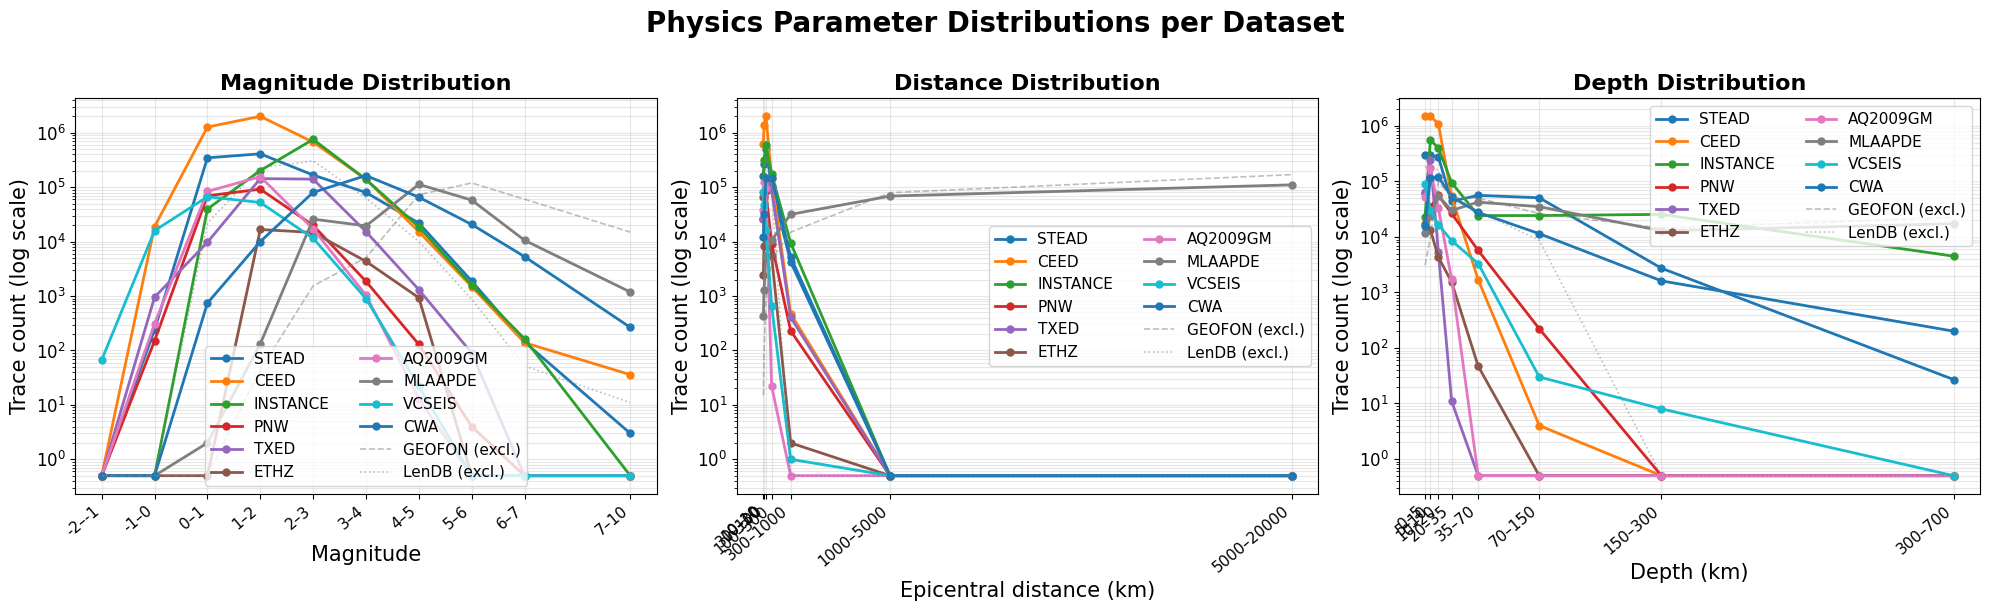

Saved → physics_distributions.png


In [48]:
# ── 1.4 — Physics Parameter Distributions ──────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

DS_ORDER  = ['stead', 'ceed', 'instancecounts', 'pnw', 'txed',
             'ethz', 'aq2009gm', 'mlaapde', 'obst2024', 'vcseis', 'cwa']
DS_LABELS = ['STEAD', 'CEED', 'INSTANCE', 'PNW', 'TXED',
             'ETHZ', 'AQ2009GM', 'MLAAPDE', 'OBST2024', 'VCSEIS', 'CWA']
DS_EXCLUDED    = ['geofon', 'lendb']
DS_EXCL_LABELS = ['GEOFON (excl.)', 'LenDB (excl.)']

COLORS = plt.cm.tab10.colors

def centres(edges): return [(edges[i]+edges[i+1])/2 for i in range(len(edges)-1)]
mag_centres   = centres(mag_bins)
depth_centres = centres(depth_bins)
dist_centres  = centres(dist_bins)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Physics Parameter Distributions per Dataset', fontsize=20, fontweight='bold', y=1.01)
ax_mag, ax_dist, ax_depth = axes

for idx, (ds, label) in enumerate(zip(DS_ORDER, DS_LABELS)):
    if ds not in results:
        continue
    r     = results[ds]
    color = COLORS[idx % len(COLORS)]
    kw    = dict(marker='o', ms=5, lw=2.0, label=label, color=color)
    if any(v > 0 for v in r['mag']):
        ax_mag.semilogy(mag_centres, [max(v, 0.5) for v in r['mag']], **kw)
    if any(v > 0 for v in r['dist']):
        ax_dist.semilogy(dist_centres, [max(v, 0.5) for v in r['dist']], **kw)
    if any(v > 0 for v in r['depth']):
        ax_depth.semilogy(depth_centres, [max(v, 0.5) for v in r['depth']], **kw)

grey_styles = ['--', ':']
for i, (ds, label) in enumerate(zip(DS_EXCLUDED, DS_EXCL_LABELS)):
    if ds not in results:
        continue
    r  = results[ds]
    ls = grey_styles[i % len(grey_styles)]
    kw = dict(ls=ls, lw=1.2, color='grey', alpha=0.5, label=label)
    if any(v > 0 for v in r['mag']):
        ax_mag.semilogy(mag_centres, [max(v, 0.5) for v in r['mag']], **kw)
    if any(v > 0 for v in r['dist']):
        ax_dist.semilogy(dist_centres, [max(v, 0.5) for v in r['dist']], **kw)
    if any(v > 0 for v in r['depth']):
        ax_depth.semilogy(depth_centres, [max(v, 0.5) for v in r['depth']], **kw)

for ax, xlabel, title, centres_arr, bin_arr in [
    (ax_mag,   'Magnitude',               'Magnitude Distribution',  mag_centres,   mag_bins),
    (ax_dist,  'Epicentral distance (km)', 'Distance Distribution',   dist_centres,  dist_bins),
    (ax_depth, 'Depth (km)',              'Depth Distribution',      depth_centres, depth_bins),
]:
    ax.set_xlabel(xlabel, fontsize=15)
    ax.set_ylabel('Trace count (log scale)', fontsize=15)
    ax.set_title(title, fontsize=16, fontweight='bold')
    ax.set_xticks(centres_arr)
    ax.set_xticklabels(
        [f'{b}–{bin_arr[i+1]}' for i, b in enumerate(bin_arr[:-1])],
        rotation=40, ha='right', fontsize=11,
    )
    ax.tick_params(axis='y', labelsize=12)
    ax.legend(fontsize=11, ncol=2)
    ax.grid(True, which='both', alpha=0.3)
    ax.yaxis.set_minor_formatter(mticker.NullFormatter())
    ax.set_facecolor('white')

plt.tight_layout()
plt.savefig('physics_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → physics_distributions.png')


stead               :  1,030,231 valid S-P pairs
ceed                :  4,140,530 valid S-P pairs
instancecounts      :    713,875 valid S-P pairs
pnw                 :    183,909 valid S-P pairs
txed                :    312,224 valid S-P pairs
ethz                :     16,401 valid S-P pairs
aq2009gm            :     88,102 valid S-P pairs
obst2024            :     35,384 valid S-P pairs
vcseis              :    147,843 valid S-P pairs
cwa                 :    209,848 valid S-P pairs
mlaapde             :      1,462 valid S-P pairs


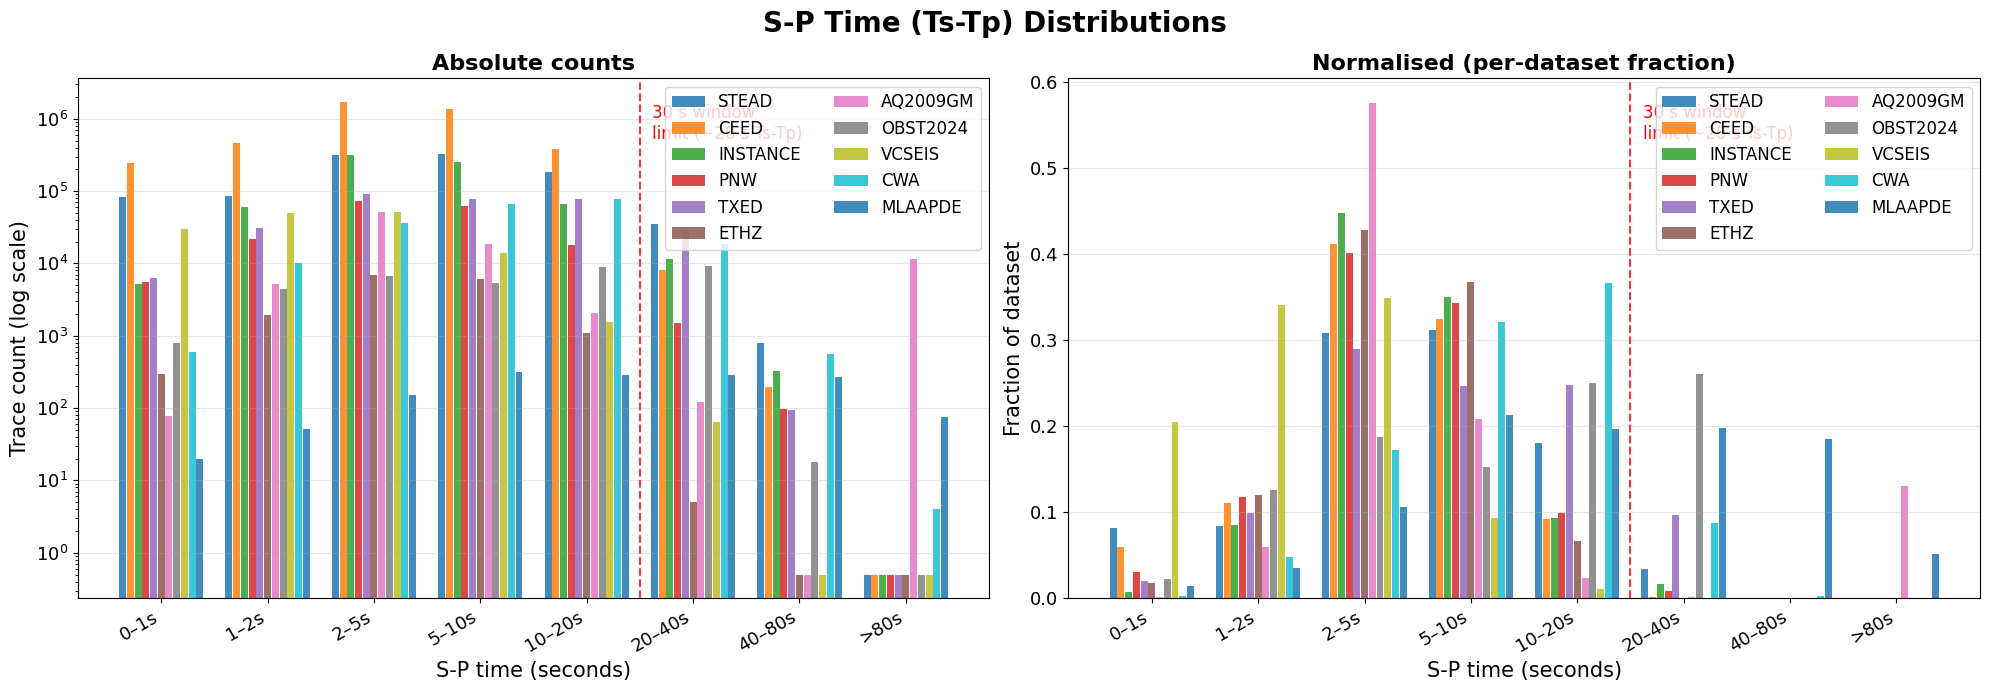

Saved → sp_time_distributions.png

Dataset               median Ts-Tp   % within 20s    % >20s
------------------------------------------------------------
STEAD                        5–10s          96.5%      3.5%
CEED                          2–5s          99.8%      0.2%
INSTANCE                      2–5s          98.3%      1.7%
PNW                           2–5s          99.1%      0.9%
TXED                         5–10s          90.3%      9.7%
ETHZ                          2–5s         100.0%      0.0%
AQ2009GM                      2–5s          86.8%     13.2%
OBST2024                    10–20s          73.8%     26.2%
VCSEIS                        1–2s         100.0%      0.0%
CWA                          5–10s          91.0%      9.0%
MLAAPDE                     10–20s          56.6%     43.4%


In [49]:
# ── 1.4b — S-P Time (Ts-Tp) Distributions ──────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from pathlib import Path

# Dataset config: p_col, s_col, sr_col, p_fallbacks, s_fallbacks
SP_DATASETS = {
    'stead':          {'p': 'trace_p_arrival_sample', 's': 'trace_s_arrival_sample',  'sr': None,                     'p_fb': [], 's_fb': []},
    'ceed':           {'p': 'trace_p_arrival_sample', 's': 'trace_s_arrival_sample',  'sr': 'trace_sampling_rate_hz', 'p_fb': [], 's_fb': []},
    'instancecounts': {'p': 'trace_P_arrival_sample', 's': 'trace_S_arrival_sample',  'sr': None,                     'p_fb': [], 's_fb': []},
    'pnw':            {'p': 'trace_P_arrival_sample', 's': 'trace_S_arrival_sample',  'sr': 'trace_sampling_rate_hz', 'p_fb': [], 's_fb': []},
    'txed':           {'p': 'trace_p_arrival_sample', 's': 'trace_s_arrival_sample',  'sr': None,                     'p_fb': [], 's_fb': []},
    'ethz':           {'p': 'trace_P1_arrival_sample', 's': 'trace_S1_arrival_sample', 'sr': 'trace_sampling_rate_hz',
                       'p_fb': ['trace_Pg_arrival_sample', 'trace_Pn_arrival_sample'],
                       's_fb': ['trace_Sg_arrival_sample', 'trace_Sn_arrival_sample']},
    'aq2009gm':       {'p': 'trace_p_arrival_sample', 's': 'trace_s_arrival_sample',  'sr': None,                     'p_fb': [], 's_fb': []},
    'obst2024':       {'p': 'trace_p_arrival_sample', 's': 'trace_s_arrival_sample',  'sr': 'trace_sampling_rate_hz', 'p_fb': [], 's_fb': []},
    'vcseis':         {'p': 'trace_p_arrival_sample', 's': 'trace_s_arrival_sample',  'sr': 'trace_sampling_rate_hz', 'p_fb': [], 's_fb': []},
    'cwa':            {'p': 'trace_p_arrival_sample', 's': 'trace_s_arrival_sample',  'sr': 'trace_sampling_rate_hz', 'p_fb': [], 's_fb': []},
    'mlaapde':        {'p': 'trace_P_arrival_sample', 's': 'trace_S_arrival_sample',  'sr': 'trace_sampling_rate_hz',
                       'p_fb': ['trace_Pn_arrival_sample', 'trace_Pg_arrival_sample'],
                       's_fb': ['trace_Sn_arrival_sample', 'trace_Sg_arrival_sample']},
}

SP_EDGES   = [0, 1, 2, 5, 10, 20, 40, 80, 200]
SP_LABELS  = ['0–1s', '1–2s', '2–5s', '5–10s', '10–20s', '20–40s', '40–80s', '>80s']
DEFAULT_SR = 100.0

sp_results = {}

for ds_name, cfg in SP_DATASETS.items():
    files = get_meta_files(ds_name)
    if not files:
        print(f'SKIP {ds_name}: no metadata found')
        continue

    counts  = np.zeros(len(SP_EDGES) - 1, dtype=np.int64)
    n_valid = 0

    for meta_path in files:
        all_cols = set(pd.read_csv(meta_path, nrows=0).columns)
        wanted   = ([cfg['p']] + cfg['p_fb'] + [cfg['s']] + cfg['s_fb'] +
                    ([cfg['sr']] if cfg['sr'] else []))
        usecols  = [c for c in wanted if c in all_cols]

        has_p = cfg['p'] in all_cols or any(c in all_cols for c in cfg['p_fb'])
        has_s = cfg['s'] in all_cols or any(c in all_cols for c in cfg['s_fb'])
        if not has_p or not has_s:
            continue

        for chunk in pd.read_csv(meta_path, usecols=usecols,
                                 chunksize=200_000, low_memory=False):
            p_series = chunk.get(cfg['p'], pd.Series(dtype=float))
            for fb in cfg['p_fb']:
                if fb in chunk.columns:
                    p_series = p_series.fillna(chunk[fb])
            s_series = chunk.get(cfg['s'], pd.Series(dtype=float))
            for fb in cfg['s_fb']:
                if fb in chunk.columns:
                    s_series = s_series.fillna(chunk[fb])

            mask  = p_series.notna() & s_series.notna()
            p_arr = p_series[mask].values
            s_arr = s_series[mask].values
            if len(p_arr) == 0:
                continue

            sr = (chunk.loc[mask, cfg['sr']].fillna(DEFAULT_SR).clip(lower=1).values
                  if cfg['sr'] and cfg['sr'] in chunk.columns
                  else np.full(len(p_arr), DEFAULT_SR))

            sp = (s_arr - p_arr) / sr
            sp = sp[np.isfinite(sp) & (sp > 0)]
            counts  += np.histogram(sp, bins=SP_EDGES)[0]
            n_valid += len(sp)

    sp_results[ds_name] = counts
    print(f'{ds_name:20s}: {n_valid:>10,} valid S-P pairs')

# ── Plot ──────────────────────────────────────────────────────────────────────
DS_DISPLAY = {
    'stead': 'STEAD', 'ceed': 'CEED', 'instancecounts': 'INSTANCE',
    'pnw': 'PNW', 'txed': 'TXED', 'ethz': 'ETHZ', 'aq2009gm': 'AQ2009GM',
    'obst2024': 'OBST2024', 'vcseis': 'VCSEIS', 'cwa': 'CWA', 'mlaapde': 'MLAAPDE',
}
COLORS = plt.cm.tab10.colors
LIMIT_IDX = SP_LABELS.index('10–20s')   # axvline at x = LIMIT_IDX + 0.5

fig, axes = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle('S-P Time (Ts-Tp) Distributions', fontsize=20, fontweight='bold')
ax_log, ax_frac = axes
x     = np.arange(len(SP_LABELS))
width = 0.8 / len(sp_results)

for idx, (ds, counts) in enumerate(sp_results.items()):
    offset = (idx - len(sp_results) / 2 + 0.5) * width
    label  = DS_DISPLAY.get(ds, ds)
    color  = COLORS[idx % len(COLORS)]
    ax_log.bar(x + offset, np.maximum(counts, 0.5), width=width * 0.9,
               label=label, color=color, alpha=0.85)
    total = counts.sum()
    if total > 0:
        ax_frac.bar(x + offset, counts / total, width=width * 0.9,
                    label=label, color=color, alpha=0.85)

for ax in axes:
    ax.set_xlabel('S-P time (seconds)', fontsize=15)
    ax.set_xticks(x)
    ax.set_xticklabels(SP_LABELS, rotation=30, ha='right', fontsize=13)
    ax.tick_params(axis='y', labelsize=13)
    ax.legend(fontsize=12, ncol=2)
    ax.grid(True, axis='y', alpha=0.3)
    ax.axvline(x=LIMIT_IDX + 0.5, color='red', linestyle='--', linewidth=1.5, alpha=0.8)
    ax.set_facecolor('white')

ax_log.set_yscale('log')
ax_log.set_ylabel('Trace count (log scale)', fontsize=15)
ax_log.set_title('Absolute counts', fontsize=16, fontweight='bold')
ax_log.text(0.63, 0.95, '30 s window\nlimit (~20 s Ts-Tp)',
            transform=ax_log.transAxes, color='red', fontsize=12,
            va='top', ha='left')

ax_frac.set_ylabel('Fraction of dataset', fontsize=15)
ax_frac.set_title('Normalised (per-dataset fraction)', fontsize=16, fontweight='bold')
ax_frac.text(0.63, 0.95, '30 s window\nlimit (~20 s Ts-Tp)',
             transform=ax_frac.transAxes, color='red', fontsize=12,
             va='top', ha='left')

plt.tight_layout()
plt.savefig('sp_time_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → sp_time_distributions.png')

# ── Summary table ─────────────────────────────────────────────────────────────
print(f"\n{'Dataset':20s}  {'median Ts-Tp':>12s}  {'% within 20s':>13s}  {'% >20s':>8s}")
print('-' * 60)
for ds, counts in sp_results.items():
    total = counts.sum()
    if total == 0:
        continue
    cumsum     = np.cumsum(counts)
    median_bin = SP_LABELS[np.searchsorted(cumsum, total / 2)]
    within_20  = counts[:5].sum() / total * 100
    beyond_20  = counts[5:].sum() / total * 100
    print(f"{DS_DISPLAY.get(ds, ds):20s}  {median_bin:>12s}  {within_20:>12.1f}%  {beyond_20:>7.1f}%")


### Key observations from distributions

- **Magnitude < 1:** Small events are underrepresented in all regional catalogs. The benchmark's explicit magnitude bins ensure M<3 traces are sampled equally alongside M3-6 and M>6 traces.
- **Depth > 70 km:** Comes almost entirely from INSTANCE, GEOFON, and STEAD. Deep seismicity is rare in all regional catalogs — subduction zones and MLAAPDE are the main sources.
- **Distance > 1500 km:** Covered by MLAAPDE (228K traces, mostly local due to full distance range in catalog) and GEOFON (170K traces, primarily teleseismic). GEOFON is excluded from the benchmark due to <1% S picks. MLAAPDE contributes 169,160 teleseismic traces to the benchmark pool after filtering.
- **GEOFON is primarily teleseismic:** Despite being labelled 'broadband', ~170K of 275K GEOFON traces are at >5,000 km. Its S-pick rate of 0.9% makes it unsuitable for a P+S benchmark.
- **OBST2024:** Has P+S picks but no physics metadata (magnitude, depth, distance all NaN) — treated as a flat 400-trace specialty sample rather than stratified into physics bins.
- **MLAAPDE resolves the teleseismic gap:** Earlier versions of this notebook had zero teleseismic traces because NEIC lacked depth metadata and GEOFON lacked S picks. MLAAPDE provides full 3-axis physics metadata (depth available, distance available) enabling proper stratification. The 1,350 teleseismic traces in the final benchmark come entirely from MLAAPDE.


<a id='1.4b'></a>
## 1.4b Label Quality Filtering

Alberto Aguilar (labelerrors, 2024) identified pervasive label errors in several SeisBench datasets using confident learning — traces where a trained model is systematically more confident in a different pick than the assigned label. Flagged traces are excluded from both the benchmark and any future training sets.

**Bad label counts from Aguilar's analysis:**

| Dataset | Bad labels excluded | % of dataset |
|---------|-------------------|-------------|
| INSTANCE | 92,561 | 8.0% |
| PNW | 4,970 | 2.7% |
| TXED | 4,672 | 0.9% |
| ETHZ | 895 | 2.4% |
| STEAD | 149 | 0.01% |

Datasets not yet analysed by Aguilar: CEED, MLAAPDE, OBST2024, PiSDL, VCSEIS, CWA, AQ2009. Included without bad-label filtering — noted as a limitation in the methods section.


In [50]:
from pathlib import Path
import pandas as pd

# ── UPDATE this path to wherever you saved the Albert Leonardo Aguilar CSVs ──
LABEL_ERROR_DIR = Path('../data/labelerrors/')

REPORT_MAP = {
    'stead_report':    'stead',
    'instance_report': 'instancecounts',   # SeisBench name differs from report stem
    'pnw_report':      'pnw',
    'txed_report':     'txed',
    'ethz_report':     'ethz',
    # Not yet available: ceed, mlaapde, obst2024, pisdl, vcseis, cwa, aq2009
    # Removed: iquique (dataset excluded per advisor recommendation)
}

bad_traces = {}   # ds_name → set of bad trace_name strings

for stem, ds_name in REPORT_MAP.items():
    fpath = LABEL_ERROR_DIR / f'{stem}.csv'
    if not fpath.exists():
        print(f'MISSING  {fpath}')
        continue
    df_bad = pd.read_csv(fpath, usecols=['trace_name'])
    bad_traces[ds_name] = set(df_bad['trace_name'])
    print(f'{ds_name:20s}  bad traces flagged: {len(bad_traces[ds_name]):>7,}')

print(f'\nTotal bad traces across datasets with reports: {sum(len(v) for v in bad_traces.values()):,}')
print('No Aguilar report available for: ceed, mlaapde, obst2024, pisdl, vcseis, cwa, aq2009')


stead                 bad traces flagged:     149
instancecounts        bad traces flagged:  92,561
pnw                   bad traces flagged:   4,970
txed                  bad traces flagged:   4,672
ethz                  bad traces flagged:     895

Total bad traces across datasets with reports: 103,247
No Aguilar report available for: ceed, mlaapde, obst2024, pisdl, vcseis, cwa, aq2009


<a id='1.5'></a>
## 1.5 Benchmark Construction

Build a physics-stratified benchmark covering local, regional, and teleseismic distances, with seismologically motivated bins across depth and magnitude, plus four flat-sample specialty categories.

### Design decisions

| Decision | Rationale |
|---|---|
| **CEED replaces SCEDC** | Better-quality California dataset (advisor recommendation) |
| **Iquique removed** | Data quality issues; dataset too small (advisor recommendation) |
| **P or S (not strictly both required)** | MLAAPDE teleseismic traces are almost entirely P-only — physically expected |
| **Exclude Aguilar bad labels** | Mislabeled test traces penalise correct model predictions |
| **Ts–Tp stored as diagnostic** | S-P time determines P–S separation in the 30 s waveform window |
| **Uniform within-bin sampling** | Explicit magnitude bins make GR weighting unnecessary — each bin is evaluated equally regardless of natural event rates |
| **multi_arrival flag** | VCSEIS and AQ2009 contain multiple picks per window; flag prevents false-positive penalisation |
| **clipped_flag** | CWA strong-motion records may be saturated; downstream models should be aware |

### Dataset handling

| Dataset | Handling | Reason |
|---|---|---|
| STEAD, CEED, INSTANCE, PNW, TXED | Full 3-axis physics bins | Complete metadata available |
| **ETHZ** | Full 3-axis physics bins | Regional Alpine seismicity; P1/S1 column names |
| **PiSDL** | Full 3-axis physics bins | Near-field induced; short-period sensors |
| **MLAAPDE** | Teleseismic flat · uniform sampling · P-only acceptable | Supersedes NEIC; sharded monthly |
| **OBST2024** | Flat 400-trace sample | No physics metadata |
| **VCSEIS** | Flat 200-trace sample · multi_arrival=True | Volcanic multi-arrival windows |
| **CWA** | Flat 200-trace sample · clipped_flag=True | Strong-motion accelerometer; may be clipped |
| **AQ2009** | Flat 200-trace sample · multi_arrival=True | Multiple picks per window — first P/S used |
| GEOFON, LenDB, Iquique | **Excluded** | <1% S picks / P-only / quality issues |

### Physics bins

3 × 4 × 3 = 36 physics bins · target 150 traces/bin · cap 80 traces/dataset/bin.

| Axis | Bins |
|---|---|
| **Distance** | local <150 km · regional 150–1500 km · teleseismic >1500 km |
| **Depth** | 0–15 · 15–70 · 70–300 · >300 km |
| **Magnitude** | M < 3 · M 3–6 · M > 6 |


In [51]:
def safe_usecols(meta_path, wanted):
    """Return only columns from `wanted` that exist in the CSV header."""
    existing = set(pd.read_csv(meta_path, nrows=0).columns)
    return [c for c in wanted if c in existing]


# ============================================================
# 1.5  Benchmark Construction
# Prerequisites: CACHE, haversine_km (Cell 13), bad_traces (Cell 1.4b)
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path

# ── Configuration ─────────────────────────────────────────
TARGET_PER_BIN            = 3000
MAX_PER_DATASET_PER_BIN   = 1000
MLAAPDE_TELESEISMIC_TOTAL = 1350
OBST2024_FLAT_SAMPLE      = 400
VCSEIS_FLAT_SAMPLE        = 200
CWA_FLAT_SAMPLE           = 200
RANDOM_SEED               = 42


# ── PhaseNet phase-centred evaluation window convention ───────────────────────
# Both P and S are evaluated in independent 3001-sample windows centred on the
# respective arrival. P is visible in the S-centred window only if Ts-Tp <= 15s.
PHASENET_SAMPLES_BEFORE  = 1500
S_WINDOW_P_VISIBLE_LIMIT = PHASENET_SAMPLES_BEFORE / 100.0  # 15.0s at 100 Hz


DIST_EDGES  = [0,   150,  1500, np.inf]
DIST_LABELS = ['local (<150km)', 'regional (150-1500km)', 'teleseismic (>1500km)']

DEPTH_EDGES  = [0,  15,  70,  300, np.inf]
DEPTH_LABELS = ['upper-crustal (0-15km)', 'lower-crust (15-70km)',
                'intermediate (70-300km)', 'deep-focus (>300km)']

MAG_EDGES  = [-np.inf, 3.0, 6.0, np.inf]
MAG_LABELS = ['micro (M<3)', 'moderate (M3-6)', 'large (M>6)']

# ── Dataset configurations (full 3-axis physics bins) ─────
FULL_DATASETS = {
    'stead': {
        'mag': 'source_magnitude', 'depth': 'source_depth_km', 'dist': 'source_distance_km',
        'p': 'trace_p_arrival_sample', 's': 'trace_s_arrival_sample',
        'sr': 'trace_sampling_rate_hz',
        'compute_dist': False, 'tectonic_type': 'global_mixed',
        'region': 'Global (US-heavy)', 'trained_models': ['stead'],
        'multi_arrival': False, 'clipped_flag': False,
    },
    'ceed': {
        'mag': 'source_magnitude', 'depth': 'source_depth_km', 'dist': 'path_ep_distance_km',
        'p': 'trace_p_arrival_sample', 's': 'trace_s_arrival_sample',
        'sr': 'trace_sampling_rate_hz',
        'compute_dist': False, 'tectonic_type': 'transform',
        'region': 'California', 'trained_models': [],
        'multi_arrival': False, 'clipped_flag': False,
    },
    'instancecounts': {
        'mag': 'source_magnitude', 'depth': 'source_depth_km', 'dist': 'path_ep_distance_km',
        'p': 'trace_P_arrival_sample', 's': 'trace_S_arrival_sample',
        'sr': 'trace_sampling_rate_hz',
        'compute_dist': False, 'tectonic_type': 'subduction_crustal',
        'region': 'Italy / Mediterranean', 'trained_models': ['instance'],
        'multi_arrival': False, 'clipped_flag': False,
    },
    'pnw': {
        'mag': 'preferred_source_magnitude', 'depth': 'source_depth_km', 'dist': None,
        'p': 'trace_P_arrival_sample', 's': 'trace_S_arrival_sample',
        'sr': 'trace_sampling_rate_hz',
        'compute_dist': True, 'tectonic_type': 'subduction',
        'region': 'Pacific Northwest / Cascadia', 'trained_models': [],
        'multi_arrival': False, 'clipped_flag': False,
    },
    'txed': {
        'mag': 'source_magnitude', 'depth': 'source_depth_km', 'dist': None,
        'p': 'trace_p_arrival_sample', 's': 'trace_s_arrival_sample',
        'sr': 'trace_sampling_rate_hz',
        'compute_dist': True, 'tectonic_type': 'induced',
        'region': 'Texas (induced seismicity)', 'trained_models': [],
        'multi_arrival': False, 'clipped_flag': False,
    },
    'ethz': {
        'mag': 'source_magnitude', 'depth': 'source_depth_km', 'dist': None,
        'p': 'trace_P1_arrival_sample',
        's': 'trace_S1_arrival_sample',
        'sr': 'trace_sampling_rate_hz',
        'compute_dist': True, 'tectonic_type': 'regional_tectonic',
        'region': 'Switzerland / Alpine', 'trained_models': ['ethz'],
        'multi_arrival': False, 'clipped_flag': False,
        'p_fallbacks': ['trace_Pg_arrival_sample', 'trace_Pn_arrival_sample'],
        's_fallbacks': ['trace_Sg_arrival_sample', 'trace_Sn_arrival_sample'],
    },
    'pisdl': {
        'mag': 'source_magnitude', 'depth': 'source_depth_km', 'dist': None,
        'p': 'trace_P_arrival_sample', 's': 'trace_S_arrival_sample',
        'sr': 'trace_sampling_rate_hz',
        'compute_dist': True, 'tectonic_type': 'induced_nearfield',
        'region': 'Various (induced, near-field)', 'trained_models': ['pisdl'],
        'multi_arrival': False, 'clipped_flag': False,
    },
    'aq2009gm': {
        'mag': 'source_magnitude', 'depth': 'source_depth_km', 'dist': 'path_ep_distance_km',
        'p': 'trace_p_arrival_sample', 's': 'trace_s_arrival_sample',
        'sr': 'trace_sampling_rate_hz',
        'compute_dist': False, 'tectonic_type': 'local_tectonic',
        'region': "Italy (L'Aquila, central Apennines)", 'trained_models': [],
        'multi_arrival': True, 'clipped_flag': False, 'sentinel': -9999,
    },
}

# ── Helper functions ──────────────────────────────────────

def assign_bins(series, edges, labels):
    return pd.cut(series, bins=edges, labels=labels, right=False, include_lowest=True)


def load_and_filter(meta_path, usecols, p_col, s_col, bad_set,
                    chunksize=500_000, require_s=True, require_p=True):
    chunks = []
    for chunk in pd.read_csv(meta_path, usecols=usecols, chunksize=chunksize, low_memory=False):
        if require_p and p_col in chunk.columns:
            mask = chunk[p_col].notna()
        else:
            mask = pd.Series(True, index=chunk.index)
        if require_s and s_col in chunk.columns:
            mask = mask & chunk[s_col].notna()
        chunk = chunk[mask]
        if bad_set and 'trace_name' in chunk.columns:
            chunk = chunk[~chunk['trace_name'].isin(bad_set)]
        if len(chunk) > 0:
            chunks.append(chunk)
    return pd.concat(chunks, ignore_index=True) if chunks else None


# ── Process FULL_DATASETS (3-axis physics bins) ───────────
full_traces = []

for ds_name, cfg in FULL_DATASETS.items():
    meta_files = get_meta_files(ds_name)
    if not meta_files:
        print(f'SKIP {ds_name}: no metadata found')
        continue

    all_cols = set(pd.read_csv(meta_files[0], nrows=0).columns)
    if cfg['p'] not in all_cols:
        print(f'SKIP {ds_name}: P column {cfg["p"]} not in metadata')
        continue

    sr_col = cfg['sr'] if cfg['sr'] in all_cols else None

    usecols = ['trace_name', cfg['p'], cfg['s'], cfg['mag'], cfg['depth']]
    if sr_col:
        usecols.append(sr_col)
    if cfg['dist']:
        usecols.append(cfg['dist'])
    # Always include source lat/lon for geo_region assignment
    usecols += ['source_latitude_deg', 'source_longitude_deg']
    if cfg['compute_dist']:
        usecols += ['station_latitude_deg', 'station_longitude_deg']

    for fb in cfg.get('p_fallbacks', []) + cfg.get('s_fallbacks', []):
        usecols.append(fb)

    usecols = list(dict.fromkeys(c for c in usecols if c in all_cols))

    print(f'Reading {ds_name} ({len(meta_files)} shard(s))...', end=' ', flush=True)
    raw_chunks = []
    for meta_path in meta_files:
        chunk_cols = set(pd.read_csv(meta_path, nrows=0).columns)
        safe_cols  = [c for c in usecols if c in chunk_cols]
        has_fallbacks = bool(cfg.get('p_fallbacks') or cfg.get('s_fallbacks'))
        r = load_and_filter(
            meta_path, safe_cols,
            p_col     = cfg['p'],
            s_col     = cfg['s'],
            bad_set   = bad_traces.get(ds_name, set()),
            require_p = not has_fallbacks,
            require_s = not has_fallbacks,
        )
        if r is not None:
            raw_chunks.append(r)
    if not raw_chunks:
        print('no valid traces after filtering'); continue
    raw = pd.concat(raw_chunks, ignore_index=True)

    sentinel = cfg.get('sentinel', None)
    if sentinel is not None:
        for col in [cfg['p'], cfg['s']]:
            if col in raw.columns:
                raw[col] = raw[col].replace(sentinel, np.nan)

    p_fallbacks = cfg.get('p_fallbacks', [])
    s_fallbacks = cfg.get('s_fallbacks', [])
    if p_fallbacks:
        for fb in p_fallbacks:
            if fb in raw.columns:
                raw[cfg['p']] = raw[cfg['p']].fillna(raw[fb])
    if s_fallbacks:
        for fb in s_fallbacks:
            if fb in raw.columns:
                raw[cfg['s']] = raw[cfg['s']].fillna(raw[fb])
    if p_fallbacks or s_fallbacks:
        before = len(raw)
        raw = raw[raw[cfg['p']].notna() & raw[cfg['s']].notna()].copy()
        print(f'  [{ds_name}] after fallback fill: {len(raw):,} / {before:,} traces have P+S')

    n_raw = len(raw)
    n_bad = len(bad_traces.get(ds_name, set()))

    out = pd.DataFrame()
    out['trace_name']           = raw['trace_name'].values
    out['source_month']         = None
    out['magnitude']            = raw[cfg['mag']].values if cfg['mag'] in raw.columns else np.nan
    out['depth_km']             = raw[cfg['depth']].values if cfg['depth'] in raw.columns else np.nan
    out['source_latitude_deg']  = raw['source_latitude_deg'].values  if 'source_latitude_deg'  in raw.columns else np.nan
    out['source_longitude_deg'] = raw['source_longitude_deg'].values if 'source_longitude_deg' in raw.columns else np.nan
    out['p_arrival_sample']     = raw[cfg['p']].values
    out['s_arrival_sample']     = raw[cfg['s']].values
    out['has_p_pick']           = (pd.to_numeric(raw[cfg['p']], errors='coerce').notna() & (raw[cfg['p']].fillna(0) > 0)).values
    out['has_s_pick']           = (pd.to_numeric(raw[cfg['s']], errors='coerce').notna() & (raw[cfg['s']].fillna(0) > 0)).values
    out['multi_arrival']        = cfg.get('multi_arrival', False)
    out['clipped_flag']         = cfg.get('clipped_flag', False)

    if cfg['compute_dist']:
        out['distance_km'] = haversine_km(
            raw['source_latitude_deg'].values, raw['source_longitude_deg'].values,
            raw['station_latitude_deg'].values, raw['station_longitude_deg'].values,
        )
    else:
        out['distance_km'] = raw[cfg['dist']].values if cfg['dist'] in raw.columns else np.nan

    if sr_col and sr_col in raw.columns:
        sr = raw[sr_col].values
    else:
        sr = np.full(len(raw), 100.0)
        print(f'  [{ds_name}] trace_sampling_rate_hz not found — defaulting to 100 Hz')

    out['ts_tp_s'] = np.where(
        (sr > 0) & np.isfinite(sr),
        (out['s_arrival_sample'].values - out['p_arrival_sample'].values) / sr,
        np.nan,
    )

    impossible = out['ts_tp_s'].notna() & (out['ts_tp_s'] <= 0)
    out.loc[impossible, 's_arrival_sample'] = np.nan
    out.loc[impossible, 'has_s_pick']       = False
    out.loc[impossible, 'ts_tp_s']          = np.nan

    out['evaluate_s'] = (
        out['has_s_pick'] &
        pd.to_numeric(out['s_arrival_sample'], errors='coerce').notna() &
        (out['s_arrival_sample'].values > 0)
    )
    out['p_in_s_window'] = (
        out['ts_tp_s'].notna() &
        (out['ts_tp_s'] > 0) &
        (out['ts_tp_s'] <= S_WINDOW_P_VISIBLE_LIMIT)
    ).fillna(False)

    out['dist_bin']  = assign_bins(out['distance_km'], DIST_EDGES,  DIST_LABELS)
    out['depth_bin'] = assign_bins(out['depth_km'],    DEPTH_EDGES, DEPTH_LABELS)
    out['mag_bin']   = assign_bins(out['magnitude'],   MAG_EDGES,   MAG_LABELS)

    fully_binned = out['dist_bin'].notna() & out['depth_bin'].notna() & out['mag_bin'].notna()
    out['physics_bin'] = np.where(
        fully_binned,
        out['dist_bin'].astype(str) + ' | ' + out['depth_bin'].astype(str) + ' | ' + out['mag_bin'].astype(str),
        'partial',
    )

    out['dataset']        = ds_name
    out['tectonic_type']  = cfg['tectonic_type']
    out['region']         = cfg['region']
    out['trained_models'] = ','.join(cfg['trained_models'])

    n_binned = fully_binned.sum()
    print(f'{n_raw:,} kept (bad labels excluded: {n_bad:,}) | {n_binned:,} fully binned')
    full_traces.append(out[fully_binned])


# ── Process MLAAPDE (teleseismic, P-only expected) ────────
MLAAPDE_P_COLS    = ['trace_P_arrival_sample', 'trace_Pn_arrival_sample', 'trace_Pg_arrival_sample']
MLAAPDE_S_COLS    = ['trace_S_arrival_sample', 'trace_Sn_arrival_sample', 'trace_Sg_arrival_sample']
MLAAPDE_NATIVE_SR = 40.0

def coalesce_phases(df, col_priority):
    result = pd.Series(np.nan, index=df.index)
    for col in col_priority:
        if col in df.columns:
            result = result.fillna(df[col])
    return result

print('\nReading mlaapde (sharded by month)...')
monthly_files  = get_meta_files('mlaapde')
mlaapde_traces = None

if not monthly_files:
    print('No complete MLAAPDE monthly files found in cache.')
else:
    chunks = []
    for meta_file in monthly_files:
        month = meta_file.stem.split('_')[1]
        df    = pd.read_csv(meta_file, low_memory=False)

        df['p_arrival_sample'] = coalesce_phases(df, MLAAPDE_P_COLS)
        df['s_arrival_sample'] = coalesce_phases(df, MLAAPDE_S_COLS)

        has_p = df['p_arrival_sample'].notna()
        has_s = df['s_arrival_sample'].notna()
        df    = df[has_p | has_s].copy()
        if len(df) == 0:
            continue

        out = pd.DataFrame()
        out['trace_name']           = df['trace_name'].values
        out['source_month']         = month
        out['magnitude']            = df['source_magnitude'].values    if 'source_magnitude'    in df.columns else np.nan
        out['depth_km']             = df['source_depth_km'].values     if 'source_depth_km'     in df.columns else np.nan
        out['distance_km']          = df['path_ep_distance_km'].values if 'path_ep_distance_km' in df.columns else np.nan
        out['source_latitude_deg']  = df['source_latitude_deg'].values  if 'source_latitude_deg'  in df.columns else np.nan
        out['source_longitude_deg'] = df['source_longitude_deg'].values if 'source_longitude_deg' in df.columns else np.nan
        out['p_arrival_sample']     = df['p_arrival_sample'].values
        out['s_arrival_sample']     = df['s_arrival_sample'].values
        out['has_p_pick']           = out['p_arrival_sample'].notna()
        out['has_s_pick']           = out['s_arrival_sample'].notna()
        out['multi_arrival']        = False
        out['clipped_flag']         = False
        out['ts_tp_s'] = np.where(
            out['has_p_pick'] & out['has_s_pick'],
            (out['s_arrival_sample'].values - out['p_arrival_sample'].values) / MLAAPDE_NATIVE_SR,
            np.nan)

        out['evaluate_s'] = (
            out['has_s_pick'] &
            pd.to_numeric(out['s_arrival_sample'], errors='coerce').notna() &
            (out['s_arrival_sample'].fillna(0).values > 0)
        )
        out['p_in_s_window'] = (
            out['ts_tp_s'].notna() &
            (out['ts_tp_s'] > 0) &
            (out['ts_tp_s'] <= S_WINDOW_P_VISIBLE_LIMIT)
        ).fillna(False)

        out['dist_bin']  = assign_bins(out['distance_km'], DIST_EDGES, DIST_LABELS)
        out['mag_bin']   = assign_bins(out['magnitude'],   MAG_EDGES,  MAG_LABELS)
        has_depth = out['depth_km'].notna()
        depth_series = assign_bins(out.loc[has_depth, 'depth_km'], DEPTH_EDGES, DEPTH_LABELS)
        out['depth_bin'] = np.nan
        out.loc[has_depth, 'depth_bin'] = depth_series.astype(str)

        tele_mask = out['dist_bin'] == 'teleseismic (>1500km)'
        valid     = tele_mask & out['mag_bin'].notna()
        depth_str = np.where(has_depth & valid, out['depth_bin'].astype(str), 'depth_unknown')
        out['physics_bin'] = np.where(
            valid,
            'teleseismic (>1500km) | ' + depth_str + ' | ' + out['mag_bin'].astype(str),
            'unusable')
        out['dataset']        = 'mlaapde'
        out['tectonic_type']  = 'global_teleseismic'
        out['region']         = 'Global (teleseismic)'
        out['trained_models'] = 'neic'
        chunks.append(out[valid].copy())

    if chunks:
        mlaapde_traces = pd.concat(chunks, ignore_index=True)
        n_total  = len(mlaapde_traces)
        n_p_only = (mlaapde_traces['has_p_pick'] & ~mlaapde_traces['has_s_pick']).sum()
        n_s_only = (~mlaapde_traces['has_p_pick'] & mlaapde_traces['has_s_pick']).sum()
        n_both   = (mlaapde_traces['has_p_pick'] & mlaapde_traces['has_s_pick']).sum()
        print(f'  {len(monthly_files)} monthly files | {n_total:,} teleseismic traces')
        print(f'  P+S: {n_both:,}  |  P-only: {n_p_only:,}  |  S-only: {n_s_only:,}')
    else:
        print('No teleseismic MLAAPDE traces found.')


# ── Flat-sample helper ────────────────────────────────────

def process_flat_dataset(ds_name, p_col, s_col, physics_bin_label,
                         tectonic_type, region, trained_models,
                         multi_arrival=False, clipped_flag=False,
                         require_s=True):
    """
    Load a dataset that cannot be binned by standard physics strata.
    Handles all sharding patterns via get_meta_files().
    Returns a DataFrame ready for flat sampling, or None.
    """
    meta_files = get_meta_files(ds_name)
    if not meta_files:
        print(f'SKIP {ds_name}: no metadata found')
        return None

    raw_chunks = []
    for meta_path in meta_files:
        wanted  = ['trace_name', p_col, s_col, 'trace_sampling_rate_hz',
                   'source_latitude_deg', 'source_longitude_deg']
        usecols = safe_usecols(meta_path, wanted)
        r = load_and_filter(
            meta_path, usecols,
            p_col     = p_col,
            s_col     = s_col,
            bad_set   = bad_traces.get(ds_name, set()),
            require_s = require_s,
        )
        if r is not None:
            raw_chunks.append(r)

    if not raw_chunks:
        print(f'{ds_name}: no valid traces after filtering')
        return None

    raw = pd.concat(raw_chunks, ignore_index=True)

    out = pd.DataFrame()
    out['trace_name']           = raw['trace_name'].values
    out['source_month']         = None
    out['source_latitude_deg']  = raw['source_latitude_deg'].values  if 'source_latitude_deg'  in raw.columns else np.nan
    out['source_longitude_deg'] = raw['source_longitude_deg'].values if 'source_longitude_deg' in raw.columns else np.nan
    for col in ['magnitude', 'depth_km', 'distance_km']:
        out[col] = np.nan
    out['p_arrival_sample'] = raw[p_col].values
    out['s_arrival_sample'] = raw[s_col].values if s_col in raw.columns else np.nan
    out['has_p_pick']       = raw[p_col].notna().values
    out['has_s_pick']       = raw[s_col].notna().values if s_col in raw.columns else False
    out['multi_arrival']    = multi_arrival
    out['clipped_flag']     = clipped_flag

    sr = (raw['trace_sampling_rate_hz'].values
          if 'trace_sampling_rate_hz' in raw.columns
          else np.full(len(raw), 100.0))

    out['ts_tp_s'] = np.where(
        (sr > 0) & np.isfinite(sr) & out['has_p_pick'] & out['has_s_pick'],
        (out['s_arrival_sample'].values - out['p_arrival_sample'].values) / sr,
        np.nan,
    )
    for col in ['dist_bin', 'depth_bin', 'mag_bin']:
        out[col] = np.nan
    out['physics_bin']    = physics_bin_label
    out['dataset']        = ds_name
    out['tectonic_type']  = tectonic_type
    out['region']         = region
    out['trained_models'] = trained_models

    out['evaluate_s'] = (
        out['has_s_pick'] &
        pd.to_numeric(out['s_arrival_sample'], errors='coerce').notna() &
        (out['s_arrival_sample'].fillna(0).values > 0)
    )
    out['p_in_s_window'] = False

    print(f'{ds_name}: {len(out):,} valid traces across '
          f'{len(meta_files)} shard(s) (flat sample)')
    return out


# ── Process flat-sample specialty datasets ────────────────
print('\nReading flat-sample datasets...')

obst_traces = process_flat_dataset(
    'obst2024', 'trace_p_arrival_sample', 'trace_s_arrival_sample',
    physics_bin_label='OBS_flat',
    tectonic_type='ocean_bottom', region='East Pacific Rise (OBS)',
    trained_models='obs',
)

vcseis_traces = process_flat_dataset(
    'vcseis', 'trace_p_arrival_sample', 'trace_s_arrival_sample',
    physics_bin_label='volcanic_flat',
    tectonic_type='volcanic', region='Various (volcanic networks)',
    trained_models='volpick',
    multi_arrival=True,
)

cwa_traces = process_flat_dataset(
    'cwa', 'trace_p_arrival_sample', 'trace_s_arrival_sample',
    physics_bin_label='strong_motion_flat',
    tectonic_type='strong_motion', region='Taiwan (CWA strong-motion network)',
    trained_models='',
    clipped_flag=True,
)

# AQ2009GM promoted to FULL_DATASETS (has full physics metadata)


Reading stead (1 shard(s))...   [stead] trace_sampling_rate_hz not found — defaulting to 100 Hz
1,030,082 kept (bad labels excluded: 149) | 1,023,138 fully binned
Reading ceed (65 shard(s))... 4,140,530 kept (bad labels excluded: 0) | 4,056,420 fully binned
Reading instancecounts (1 shard(s))...   [instancecounts] trace_sampling_rate_hz not found — defaulting to 100 Hz
631,167 kept (bad labels excluded: 92,561) | 631,167 fully binned
Reading pnw (1 shard(s))... 178,939 kept (bad labels excluded: 4,970) | 154,552 fully binned
Reading txed (1 shard(s))...   [txed] trace_sampling_rate_hz not found — defaulting to 100 Hz
307,559 kept (bad labels excluded: 4,672) | 307,219 fully binned
Reading ethz (1 shard(s))...   [ethz] after fallback fill: 15,763 / 35,848 traces have P+S
15,763 kept (bad labels excluded: 895) | 14,794 fully binned
Reading pisdl (1 shard(s))... 65,330 kept (bad labels excluded: 0) | 64,090 fully binned
Reading aq2009gm (10 shard(s))...   [aq2009gm] trace_sampling_rate_hz

/tmp/ipykernel_2244411/3430859494.py:352: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['lower-crust (15-70km)' 'lower-crust (15-70km)' 'lower-crust (15-70km)'
 ... 'lower-crust (15-70km)' 'lower-crust (15-70km)'
 'lower-crust (15-70km)']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  out.loc[has_depth, 'depth_bin'] = depth_series.astype(str)
/tmp/ipykernel_2244411/3430859494.py:352: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['lower-crust (15-70km)' 'intermediate (70-300km)'
 'intermediate (70-300km)' ... 'lower-crust (15-70km)'
 'lower-crust (15-70km)' 'lower-crust (15-70km)']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  out.loc[has_depth, 'depth_bin'] = depth_series.astype(str)
/tmp/ipykernel_2244411/3430859494.py:352: Future

  16 monthly files | 169,160 teleseismic traces
  P+S: 6  |  P-only: 169,137  |  S-only: 17

Reading flat-sample datasets...
obst2024: 35,394 valid traces across 1 shard(s) (flat sample)
vcseis: 147,863 valid traces across 10 shard(s) (flat sample)
cwa: 209,863 valid traces across 4 shard(s) (flat sample)


In [52]:
# ── Stratified uniform sampling ───────────────────────────
sampled = []

# A. Full 3-axis bins (STEAD, CEED, INSTANCE, PNW, TXED, ETHZ, PiSDL)
if full_traces:
    full_pool = pd.concat(full_traces, ignore_index=True)

    for bin_name, group in full_pool.groupby('physics_bin'):
        bin_samples = []
        for ds_name, ds_group in group.groupby('dataset'):
            n = min(MAX_PER_DATASET_PER_BIN, len(ds_group))
            bin_samples.append(
                ds_group.sample(n=n, random_state=RANDOM_SEED)
            )
        bin_df = pd.concat(bin_samples)
        if len(bin_df) > TARGET_PER_BIN:
            bin_df = bin_df.sample(n=TARGET_PER_BIN, random_state=RANDOM_SEED)
        sampled.append(bin_df)
    print(f"Full 3-axis bins: {sum(len(s) for s in sampled):,} traces")


# B. MLAAPDE teleseismic (P-only expected — uniform sampling)
if mlaapde_traces is not None:
    n_mlaapde      = min(MLAAPDE_TELESEISMIC_TOTAL, len(mlaapde_traces))
    mlaapde_sample = mlaapde_traces.sample(n=n_mlaapde, random_state=RANDOM_SEED)

    n_both   = (mlaapde_sample['has_p_pick'] & mlaapde_sample['has_s_pick']).sum()
    n_p_only = (mlaapde_sample['has_p_pick'] & ~mlaapde_sample['has_s_pick']).sum()
    n_s_only = (~mlaapde_sample['has_p_pick'] & mlaapde_sample['has_s_pick']).sum()
    print(f"MLAAPDE teleseismic: {n_mlaapde:,} traces "
          f"(P+S: {n_both:,} | P-only: {n_p_only:,} | S-only: {n_s_only:,})")
    sampled.append(mlaapde_sample)


# C. OBST2024 — OBS flat sample
if obst_traces is not None:
    n = min(OBST2024_FLAT_SAMPLE, len(obst_traces))
    sampled.append(obst_traces.sample(n=n, random_state=RANDOM_SEED))
    print(f"OBST2024 (OBS flat): {n:,} traces")

# D. VCSEIS — volcanic flat sample
if vcseis_traces is not None:
    n = min(VCSEIS_FLAT_SAMPLE, len(vcseis_traces))
    sampled.append(vcseis_traces.sample(n=n, random_state=RANDOM_SEED))
    print(f"VCSEIS (volcanic flat): {n:,} traces")

# E. CWA — strong-motion / clipped flat sample
if cwa_traces is not None:
    n = min(CWA_FLAT_SAMPLE, len(cwa_traces))
    sampled.append(cwa_traces.sample(n=n, random_state=RANDOM_SEED))
    print(f"CWA (strong-motion flat): {n:,} traces")

# AQ2009GM: now in full 3-axis bins (FULL_DATASETS)

benchmark = pd.concat(sampled, ignore_index=True)

# ── Assign fine-grained geographic region from source lat/lon ─────────────────
# Conditions are evaluated IN ORDER — the FIRST True condition wins (np.select).
# Sub-regions must appear BEFORE any broader region that spatially contains them.
def assign_geo_region_vec(lat_series, lon_series):
    lat = pd.to_numeric(lat_series, errors='coerce')
    lon = pd.to_numeric(lon_series, errors='coerce')

    conditions = [
        # ── No coordinates ────────────────────────────────────────────────────
        lat.isna() | lon.isna(),

        # ── North America — specific sub-regions first ────────────────────────
        (lat >= 54) & (lat <= 72) & (lon >= -170) & (lon <= -130),   # Alaska
        (lat >= 42) & (lat <= 52) & (lon >= -126) & (lon <= -116),   # Pacific Northwest
        (lat >= 36) & (lat <  42) & (lon >= -125) & (lon <= -118),   # Northern California
        (lat >= 32) & (lat <  36) & (lon >= -121) & (lon <= -114),   # Southern California
        (lat >= 25) & (lat <= 37) & (lon >= -107) & (lon <= -93),    # Texas / Oklahoma
        (lat >= 18) & (lat <= 23) & (lon >= -162) & (lon <= -154),   # Hawaii
        # Remaining North America (Canada, Mexico, rest of US)
        (lat >= 15) & (lat <= 75) & (lon >= -170) & (lon <= -50),

        # ── Caribbean / Central America ───────────────────────────────────────
        (lat >=  8) & (lat <= 24) & (lon >= -90)  & (lon <= -60),

        # ── South America ─────────────────────────────────────────────────────
        (lat >= -60) & (lat < 15) & (lon >= -82)  & (lon <= -30),

        # ── Europe — specific sub-regions first ───────────────────────────────
        # Switzerland/Alpine must precede Italy (geographically nested in the Alps)
        (lat >= 45) & (lat <= 50) & (lon >=   5)  & (lon <=  12),   # Switzerland / Alpine
        (lat >= 36) & (lat <= 48) & (lon >=   6)  & (lon <=  19),   # Italy / Apennines
        (lat >= 34) & (lat <= 42) & (lon >=  19)  & (lon <=  30),   # Greece / Aegean
        (lat >= 36) & (lat <= 43) & (lon >=  26)  & (lon <=  47),   # Turkey / Caucasus
        (lat >= 35) & (lat <= 44) & (lon >= -10)  & (lon <=   5),   # Iberian Peninsula
        (lat >= 63) & (lat <= 67) & (lon >= -25)  & (lon <= -13),   # Iceland
        # Remaining Europe (Scandinavia, Central Europe, UK, etc.)
        (lat >= 35) & (lat <= 72) & (lon >= -30)  & (lon <=  47),

        # ── Africa ────────────────────────────────────────────────────────────
        (lat >= -35) & (lat < 37) & (lon >= -20)  & (lon <=  52),

        # ── Middle East ───────────────────────────────────────────────────────
        (lat >= 10)  & (lat <= 40) & (lon >=  35) & (lon <=  65),

        # ── Asia — specific sub-regions first ─────────────────────────────────
        # Taiwan before Southeast Asia (lat/lon overlap)
        (lat >= 21)  & (lat <= 26) & (lon >= 119) & (lon <= 123),   # Taiwan
        # Japan before China (lon overlap east of ~130)
        (lat >= 24)  & (lat <= 46) & (lon >= 122) & (lon <= 148),   # Japan / Ryukyu
        (lat >= -10) & (lat <= 25) & (lon >=  95) & (lon <= 145),   # Southeast Asia
        (lat >=  6)  & (lat <= 36) & (lon >=  68) & (lon <=  92),   # India / South Asia
        (lat >= 36)  & (lat <= 55) & (lon >=  52) & (lon <=  88),   # Central Asia
        # China/East Asia after Japan so Japan wins for overlapping lon
        (lat >= 18)  & (lat <= 55) & (lon >=  88) & (lon <= 145),   # China / East Asia
        (lat >= 50)  & (lat <= 75) & (lon >=  30) & (lon <= 180),   # Russia / Siberia / Kamchatka

        # ── Pacific / Oceania ─────────────────────────────────────────────────
        (lat >= -48) & (lat <= -34) & (lon >= 166) & (lon <= 178),  # New Zealand
        (lat >= -50) & (lat <=  20) & (lon >= 130) & (lon <= 180),  # Pacific / Oceania
        (lat >= -50) & (lat <=  20) & (lon >= -180)& (lon <= -100), # Eastern Pacific
    ]

    choices = [
        'Unknown',
        # North America
        'Alaska', 'Pacific Northwest', 'Northern California', 'Southern California',
        'Texas / Oklahoma', 'Hawaii', 'North America',
        # Caribbean / South America
        'Caribbean / Central America', 'South America',
        # Europe
        'Switzerland / Alpine', 'Italy / Apennines', 'Greece / Aegean',
        'Turkey / Caucasus', 'Iberian Peninsula', 'Iceland', 'Europe',
        # Africa, Middle East
        'Africa', 'Middle East',
        # Asia
        'Taiwan', 'Japan / Ryukyu', 'Southeast Asia',
        'India / South Asia', 'Central Asia', 'China / East Asia',
        'Russia / Siberia',
        # Pacific
        'New Zealand', 'Pacific / Oceania', 'Eastern Pacific',
    ]

    return pd.Series(
        np.select(conditions, choices, default='Global/Unknown'),
        index=lat.index,
    )

benchmark['geo_region'] = assign_geo_region_vec(
    benchmark['source_latitude_deg'],
    benchmark['source_longitude_deg'],
)

print(f"\nTotal benchmark : {len(benchmark):,} traces")
print(f"  has P pick    : {benchmark['has_p_pick'].sum():,}")
print(f"  has S pick    : {benchmark['has_s_pick'].sum():,}")
print(f"  has both P+S  : {(benchmark['has_p_pick'] & benchmark['has_s_pick']).sum():,}")
print(f"  multi-arrival : {benchmark['multi_arrival'].sum():,}")
print(f"  clipped       : {benchmark['clipped_flag'].sum():,}")
print(f"  has Ts-Tp     : {benchmark['ts_tp_s'].notna().sum():,}")
print(f"\nBy dataset:")
print(benchmark.groupby('dataset')[['has_p_pick','has_s_pick','multi_arrival','clipped_flag']].sum().to_string())
print(f"\nBy geographic region:")
print(benchmark['geo_region'].value_counts().to_string())


Full 3-axis bins: 33,242 traces
MLAAPDE teleseismic: 1,350 traces (P+S: 0 | P-only: 1,350 | S-only: 0)
OBST2024 (OBS flat): 400 traces
VCSEIS (volcanic flat): 200 traces
CWA (strong-motion flat): 200 traces

Total benchmark : 35,392 traces
  has P pick    : 35,349
  has S pick    : 33,154
  has both P+S  : 33,111
  multi-arrival : 1,546
  clipped       : 200
  has Ts-Tp     : 33,111

By dataset:
                has_p_pick  has_s_pick  multi_arrival  clipped_flag
dataset                                                            
aq2009gm              1303         458           1346             0
ceed                  5435        5435              0             0
cwa                    200         200              0           200
ethz                  1458        1458              0             0
instancecounts        9776        9776              0             0
mlaapde               1350           0              0             0
obst2024               400         400              0    

/tmp/ipykernel_2244411/1056259040.py:55: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  benchmark = pd.concat(sampled, ignore_index=True)
/tmp/ipykernel_2244411/1056259040.py:55: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  benchmark = pd.concat(sampled, ignore_index=True)


In [53]:
# Save benchmark manifest
output_cols = [
    'dataset', 'trace_name', 'source_month',
    'tectonic_type', 'region', 'geo_region', 'trained_models',
    'source_latitude_deg', 'source_longitude_deg',
    'magnitude', 'depth_km', 'distance_km', 'ts_tp_s',
    'p_arrival_sample', 's_arrival_sample',
    'has_p_pick', 'has_s_pick',
    'evaluate_s',
    'p_in_s_window',
    'multi_arrival', 'clipped_flag',
    'dist_bin', 'depth_bin', 'mag_bin', 'physics_bin',
]

benchmark[output_cols].to_csv('benchmark_manifest.csv', index=False)
print(f"Saved benchmark_manifest.csv  ({len(benchmark):,} traces)")
print(f"Datasets: {sorted(benchmark['dataset'].unique())}")
print(f"New columns vs v1: multi_arrival, clipped_flag, geo_region, source_latitude_deg, source_longitude_deg")


Saved benchmark_manifest.csv  (35,392 traces)
Datasets: ['aq2009gm', 'ceed', 'cwa', 'ethz', 'instancecounts', 'mlaapde', 'obst2024', 'pisdl', 'pnw', 'stead', 'txed', 'vcseis']
New columns vs v1: multi_arrival, clipped_flag, geo_region, source_latitude_deg, source_longitude_deg


<a id='1.6'></a>
## 1.6 Benchmark Summary & Visualisation

Complete breakdown of the final benchmark and summary figures.

**Manifest columns added in this version:**
- `geo_region` — fine-grained geographic region derived from `source_latitude_deg` / `source_longitude_deg` using rule-based lat/lon classification (e.g. *Northern California*, *Pacific Northwest*, *Italy / Apennines*, *Switzerland / Alpine*)
- `source_latitude_deg`, `source_longitude_deg` — source coordinates carried through from raw metadata
- `evaluate_s` — flag: S-centred evaluation window is valid for this trace
- `p_in_s_window` — flag: P is visible in the S-centred window (Ts-Tp ≤ 15 s)
- `multi_arrival`, `clipped_flag` — specialty dataset flags


In [54]:
print(f"Total traces: {len(benchmark):,}")

# has_s_pick is no longer universal — MLAAPDE is mostly P-only
print(f"  Has P pick : {benchmark['has_p_pick'].sum():,}")
print(f"  Has S pick : {benchmark['has_s_pick'].sum():,}")
print(f"  Has both   : {(benchmark['has_p_pick'] & benchmark['has_s_pick']).sum():,}")
print(f"Ts-Tp available: {benchmark['ts_tp_s'].notna().sum():,} / {len(benchmark):,}")

print(f"\n--- By dataset ---")
ds_summary = benchmark.groupby('dataset').agg(
    count        = ('dataset',    'size'),
    n_p          = ('has_p_pick', 'sum'),
    n_s          = ('has_s_pick', 'sum'),
    median_ts_tp = ('ts_tp_s',    'median'),
).sort_values('count', ascending=False)
for idx, row in ds_summary.iterrows():
    ts = f"{row['median_ts_tp']:.1f}s" if pd.notna(row['median_ts_tp']) else "N/A"
    print(f"  {idx:20s}  n={int(row['count']):>5}  "
          f"P={int(row['n_p']):>5}  S={int(row['n_s']):>5}  median Ts-Tp={ts}")

print(f"\n--- By distance ---")
for db in DIST_LABELS:
    print(f"  {db:35s}  {(benchmark['dist_bin'] == db).sum():>5}")
print(f"  {'missing (OBS)':35s}  {benchmark['dist_bin'].isna().sum():>5}")

print(f"\n--- By depth ---")
for db in DEPTH_LABELS:
    print(f"  {db:35s}  {(benchmark['depth_bin'] == db).sum():>5}")
print(f"  {'missing (MLAAPDE no-depth / OBS)':35s}  {benchmark['depth_bin'].isna().sum():>5}")

print(f"\n--- By magnitude ---")
for mb in MAG_LABELS:
    print(f"  {mb:35s}  {(benchmark['mag_bin'] == mb).sum():>5}")
print(f"  {'missing (Iquique + OBS)':35s}  {benchmark['mag_bin'].isna().sum():>5}")

print(f"\n--- Ts-Tp distribution (seconds) ---")
tp_bins   = [0, 2, 5, 10, 20, 50]
tp_labels = ['0-2s', '2-5s', '5-10s', '10-20s', '20-50s', '>50s']
tp_binned = pd.cut(benchmark['ts_tp_s'], bins=tp_bins + [np.inf], labels=tp_labels, right=False)
for lb in tp_labels:
    print(f"  {lb:12s}  {(tp_binned == lb).sum():>5}")
print(f"  {'N/A (P-only or S-only)':12s}  {benchmark['ts_tp_s'].isna().sum():>5}")

print(f"\n--- Fair evaluation usage ---")
print("When evaluating PhaseNet/stead, filter out in-domain traces:")
print("  df[~df['trained_models'].str.contains('stead')]")


print("--- Evaluation availability ---")
n_eval_p   = benchmark['has_p_pick'].sum()
n_eval_s   = benchmark['evaluate_s'].sum()
n_p_in_sw  = benchmark['p_in_s_window'].sum()
n_p_out_sw = (benchmark['evaluate_s'] & ~benchmark['p_in_s_window']).sum()

print(f"  P-centred passes  : {n_eval_p:,}  traces")
print(f"  S-centred passes  : {n_eval_s:,}  traces")
print(f"    of which P also visible in S window : {n_p_in_sw:,}  (Ts-Tp <= 15s)")
print(f"    of which P absent from S window     : {n_p_out_sw:,}  (Ts-Tp >  15s)")
print()
print("  Step 2 filter usage:")
print("    P residuals  → benchmark[benchmark['has_p_pick']]")
print("    S residuals  → benchmark[benchmark['evaluate_s']]")
print("    Ts-Tp effect → compare s_residuals where p_in_s_window T vs F")



print(f"\n--- Pick availability breakdown ---")
n_both   = (benchmark['has_p_pick'] & benchmark['has_s_pick']).sum()
n_p_only = (benchmark['has_p_pick'] & ~benchmark['has_s_pick']).sum()
n_s_only = (~benchmark['has_p_pick'] & benchmark['has_s_pick']).sum()
print(f"  P + S (complete)  : {n_both:,}")
print(f"  P only            : {n_p_only:,}  (MLAAPDE teleseismic)")
print(f"  S only            : {n_s_only:,}  (MLAAPDE teleseismic)")
print(f"\n  P-recall  → evaluate on {benchmark['has_p_pick'].sum():,} traces  (filter: benchmark[benchmark['has_p_pick']])")
print(f"  S-recall  → evaluate on {benchmark['has_s_pick'].sum():,} traces  (filter: benchmark[benchmark['has_s_pick']])")
print(f"  Ts-Tp     → only meaningful on {n_both:,} traces with both picks")

Total traces: 35,392
  Has P pick : 35,349
  Has S pick : 33,154
  Has both   : 33,111
Ts-Tp available: 33,111 / 35,392

--- By dataset ---
  instancecounts        n= 9776  P= 9776  S= 9776  median Ts-Tp=20.7s
  stead                 n= 9360  P= 9360  S= 9360  median Ts-Tp=19.2s
  ceed                  n= 5435  P= 5435  S= 5435  median Ts-Tp=18.2s
  pnw                   n= 2841  P= 2841  S= 2841  median Ts-Tp=9.8s
  txed                  n= 2261  P= 2261  S= 2261  median Ts-Tp=19.1s
  ethz                  n= 1458  P= 1458  S= 1458  median Ts-Tp=5.4s
  mlaapde               n= 1350  P= 1350  S=    0  median Ts-Tp=N/A
  aq2009gm              n= 1346  P= 1303  S=  458  median Ts-Tp=3.7s
  pisdl                 n=  765  P=  765  S=  765  median Ts-Tp=4.8s
  obst2024              n=  400  P=  400  S=  400  median Ts-Tp=10.1s
  cwa                   n=  200  P=  200  S=  200  median Ts-Tp=9.1s
  vcseis                n=  200  P=  200  S=  200  median Ts-Tp=1.8s

--- By distance ---
  local

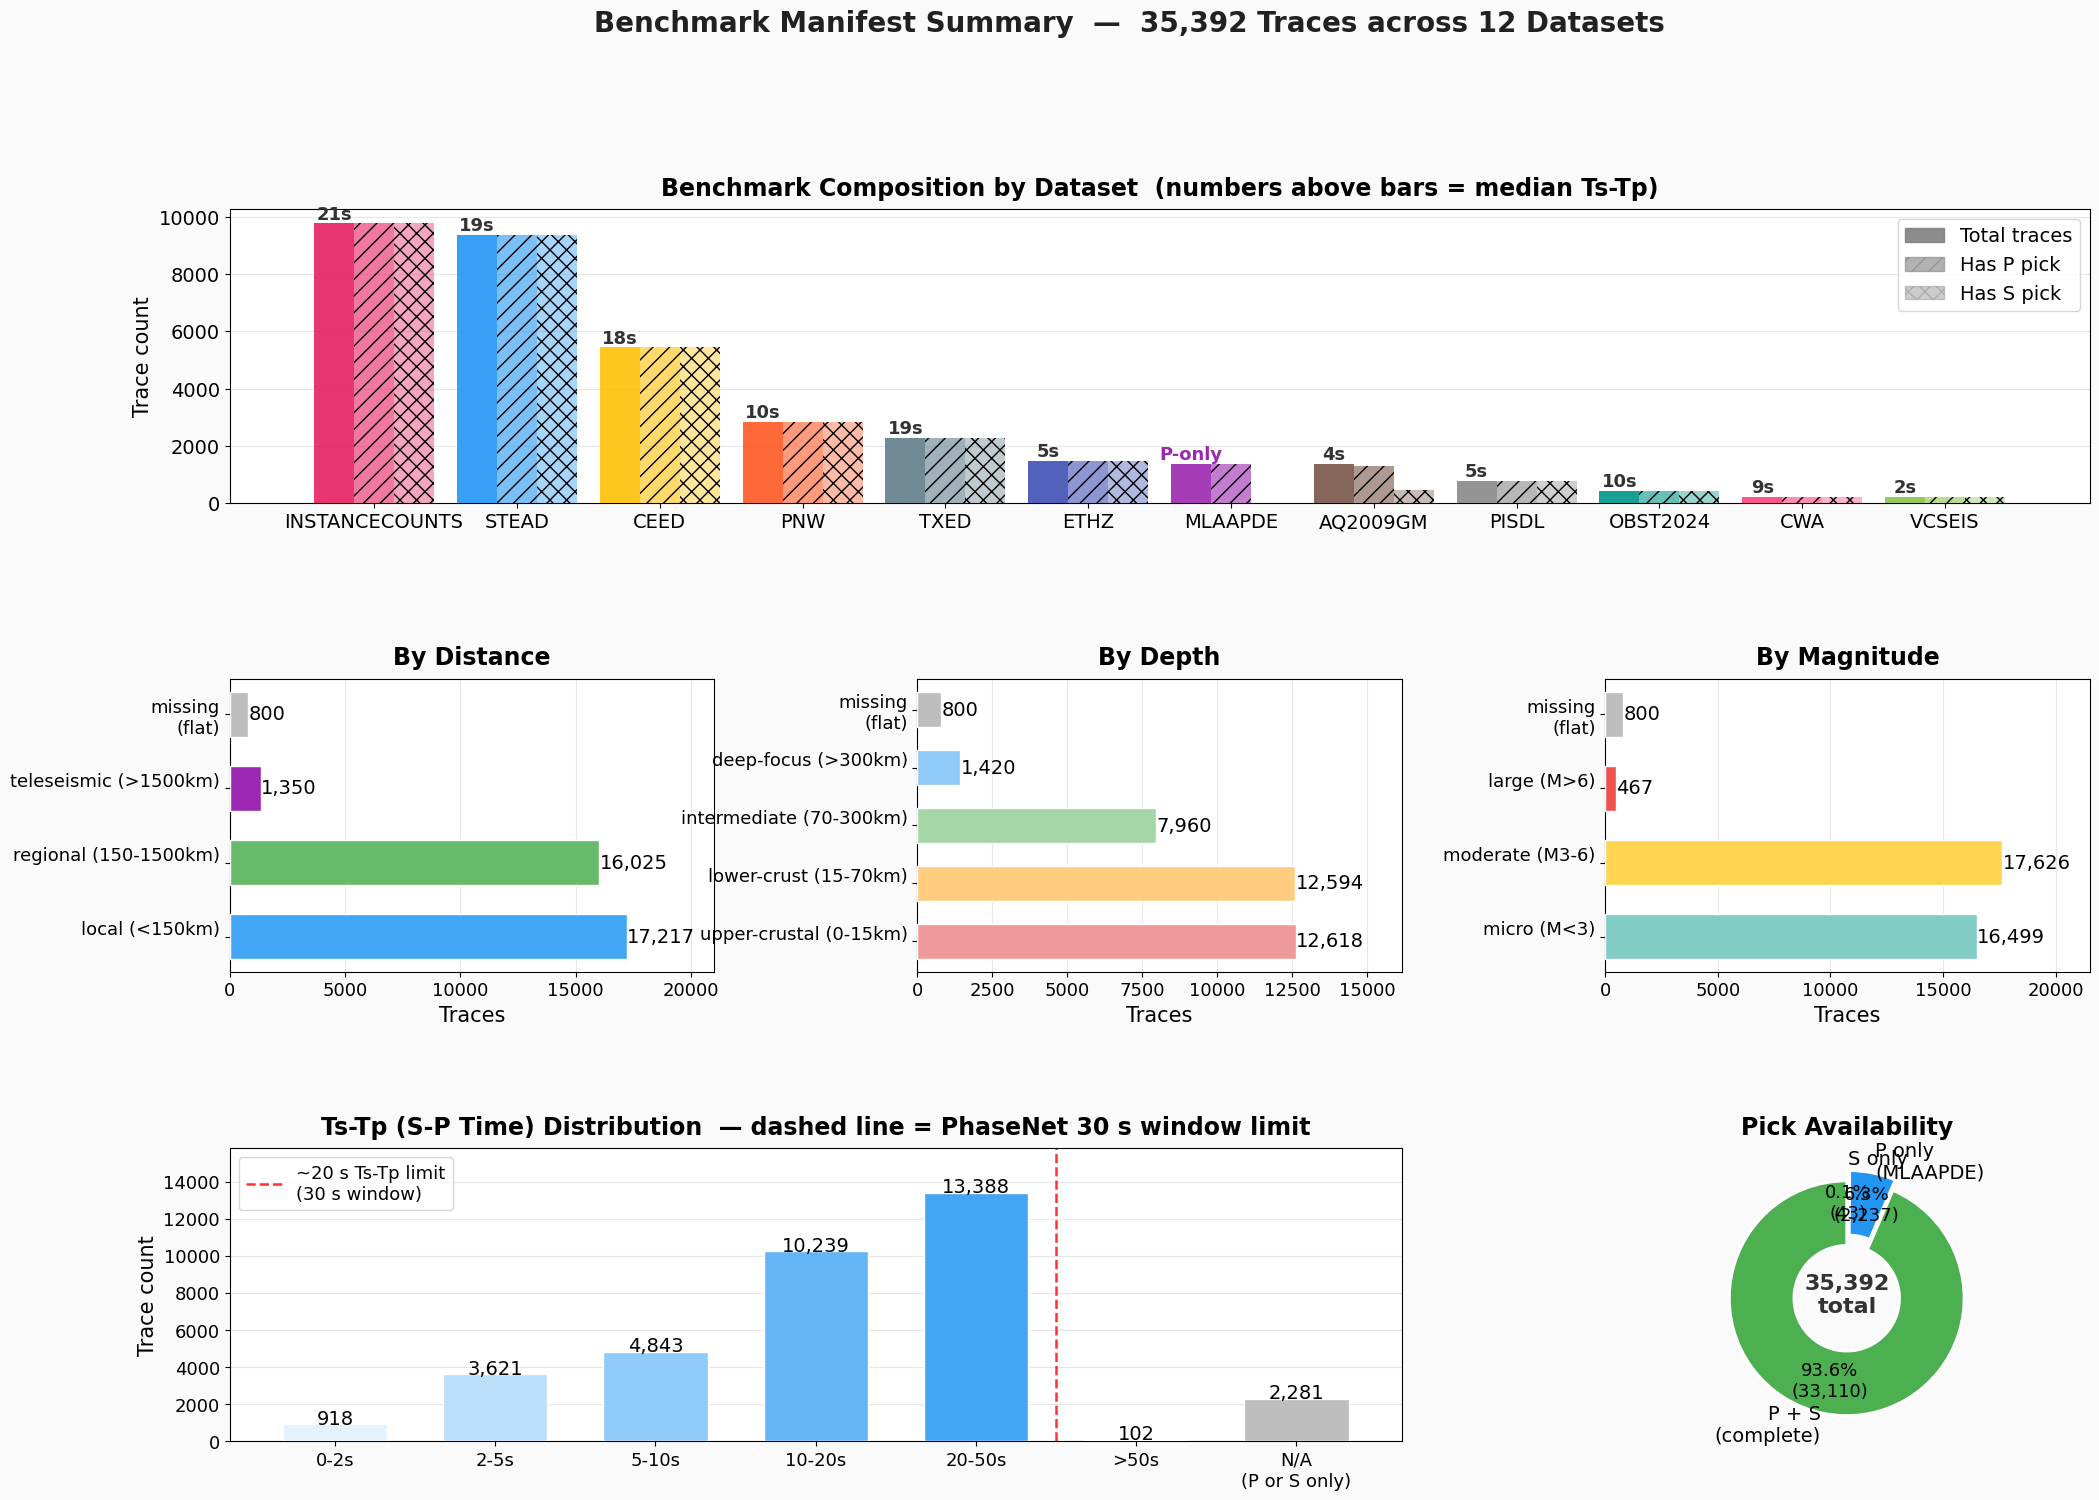

Saved → benchmark_summary.png


In [55]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd

C_P    = '#2196F3'
C_S    = '#FF9800'
C_BOTH = '#4CAF50'
C_MISS = '#BDBDBD'
C_TELE = '#9C27B0'

DS_COLORS = {
    'mlaapde':        '#9C27B0',
    'instancecounts': '#E91E63',
    'stead':          '#2196F3',
    'obst2024':       '#009688',
    'pnw':            '#FF5722',
    'ceed':           '#FFC107',
    'aq2009gm':       '#795548',
    'txed':           '#607D8B',
    'ethz':           '#3F51B5',
    'vcseis':         '#8BC34A',
    'cwa':            '#FF4081',
}

datasets = (benchmark.groupby('dataset').size()
            .sort_values(ascending=False).index.tolist())

ds_summary = benchmark.groupby('dataset').agg(
    n       = ('dataset',    'size'),
    n_p     = ('has_p_pick', 'sum'),
    n_s     = ('has_s_pick', 'sum'),
    med_tsp = ('ts_tp_s',    'median'),
)

ds_n    = [ds_summary.loc[d, 'n']       for d in datasets]
ds_p    = [ds_summary.loc[d, 'n_p']     for d in datasets]
ds_s    = [ds_summary.loc[d, 'n_s']     for d in datasets]
ds_tstp = [None if pd.isna(ds_summary.loc[d, 'med_tsp'])
           else float(ds_summary.loc[d, 'med_tsp']) for d in datasets]

dist_labels = [f'{db}\n' for db in DIST_LABELS] + ['missing\n(flat)']
dist_counts = ([(benchmark['dist_bin'] == db).sum() for db in DIST_LABELS]
               + [int(benchmark['dist_bin'].isna().sum())])
dist_colors = ['#42A5F5', '#66BB6A', C_TELE, C_MISS]

depth_labels = [f'{db}\n' for db in DEPTH_LABELS] + ['missing\n(flat)']
depth_counts = ([(benchmark['depth_bin'] == db).sum() for db in DEPTH_LABELS]
                + [int(benchmark['depth_bin'].isna().sum())])
depth_colors = ['#EF9A9A', '#FFCC80', '#A5D6A7', '#90CAF9', C_MISS]

mag_labels = [f'{mb}\n' for mb in MAG_LABELS] + ['missing\n(flat)']
mag_counts = ([(benchmark['mag_bin'] == mb).sum() for mb in MAG_LABELS]
              + [int(benchmark['mag_bin'].isna().sum())])
mag_colors = ['#80CBC4', '#FFD54F', '#EF5350', C_MISS]

tp_bin_edges  = [0, 2, 5, 10, 20, 50, np.inf]
tp_bin_labels = ['0-2s', '2-5s', '5-10s', '10-20s', '20-50s', '>50s']
tp_binned = pd.cut(benchmark['ts_tp_s'].dropna(), bins=tp_bin_edges,
                   labels=tp_bin_labels, right=False)
tstp_labels = tp_bin_labels + ['N/A\n(P or S only)']
tstp_counts = ([int((tp_binned == lb).sum()) for lb in tp_bin_labels]
               + [int(benchmark['ts_tp_s'].isna().sum())])
tstp_colors = ['#E3F2FD', '#BBDEFB', '#90CAF9', '#64B5F6', '#42A5F5', '#1565C0', C_MISS]

total_traces = len(benchmark)
n_datasets   = len(datasets)

# ── Figure ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(24, 16))
fig.patch.set_facecolor('#FAFAFA')
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.60, wspace=0.42)

TKW = dict(fontsize=17, fontweight='bold', pad=10)
LKW = dict(fontsize=15)
TiKW = dict(fontsize=15)

# Panel 1 — dataset breakdown (full width)
ax1 = fig.add_subplot(gs[0, :])
x, w = np.arange(len(datasets)), 0.28

bars_n = ax1.bar(x - w, ds_n, width=w,
                 color=[DS_COLORS.get(d, '#888') for d in datasets],
                 label='Total', alpha=0.9, zorder=3)
bars_p = ax1.bar(x,     ds_p, width=w,
                 color=[DS_COLORS.get(d, '#888') for d in datasets],
                 label='Has P', alpha=0.6, zorder=3, hatch='//')
bars_s = ax1.bar(x + w, ds_s, width=w,
                 color=[DS_COLORS.get(d, '#888') for d in datasets],
                 label='Has S', alpha=0.4, zorder=3, hatch='xx')

for bar, ts in zip(bars_n, ds_tstp):
    label_txt = f'{ts:.0f}s' if ts is not None else 'P-only'
    color_txt = '#333333' if ts is not None else C_TELE
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 15,
             label_txt, ha='center', va='bottom', fontsize=13,
             color=color_txt, fontweight='bold')

ax1.set_xticks(x)
ax1.set_xticklabels([d.upper() for d in datasets], fontsize=14)
ax1.set_ylabel('Trace count', **LKW)
ax1.set_title('Benchmark Composition by Dataset  (numbers above bars = median Ts-Tp)', **TKW)
ax1.set_facecolor('white')
ax1.yaxis.grid(True, alpha=0.3, zorder=0)
ax1.set_axisbelow(True)
ax1.tick_params(axis='y', labelsize=14)
total_patch = mpatches.Patch(color='grey', alpha=0.9, label='Total traces')
p_patch     = mpatches.Patch(color='grey', alpha=0.6, hatch='//', label='Has P pick')
s_patch     = mpatches.Patch(color='grey', alpha=0.4, hatch='xx', label='Has S pick')
ax1.legend(handles=[total_patch, p_patch, s_patch], fontsize=14, loc='upper right')

def _barh_panel(ax, labels, counts, colors, title, xlim_factor=1.25):
    bars = ax.barh(labels, counts, color=colors, edgecolor='white', height=0.6, zorder=3)
    for bar, count in zip(bars, counts):
        ax.text(bar.get_width() + 15, bar.get_y() + bar.get_height() / 2,
                f'{count:,}', va='center', fontsize=14)
    ax.set_xlim(0, max(counts) * xlim_factor)
    ax.set_title(title, **TKW)
    ax.set_xlabel('Traces', **LKW)
    ax.tick_params(axis='both', labelsize=13)
    ax.set_facecolor('white')
    ax.xaxis.grid(True, alpha=0.3, zorder=0)
    ax.set_axisbelow(True)

_barh_panel(fig.add_subplot(gs[1, 0]), dist_labels,  dist_counts,  dist_colors,  'By Distance',   1.22)
_barh_panel(fig.add_subplot(gs[1, 1]), depth_labels, depth_counts, depth_colors, 'By Depth',      1.28)
_barh_panel(fig.add_subplot(gs[1, 2]), mag_labels,   mag_counts,   mag_colors,   'By Magnitude',  1.22)

# Panel 5 — Ts-Tp
ax5 = fig.add_subplot(gs[2, :2])
bars = ax5.bar(tstp_labels, tstp_counts, color=tstp_colors, edgecolor='white', width=0.65, zorder=3)
for bar, count in zip(bars, tstp_counts):
    ax5.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
             f'{count:,}', ha='center', fontsize=14)
ax5.set_ylabel('Trace count', **LKW)
ax5.set_title('Ts-Tp (S-P Time) Distribution  — dashed line = PhaseNet 30 s window limit', **TKW)
ax5.axvline(x=4.5, color='red', linestyle='--', linewidth=1.8, alpha=0.8,
            label='~20 s Ts-Tp limit\n(30 s window)')
ax5.set_ylim(0, max(tstp_counts) * 1.18)
ax5.legend(fontsize=13, loc='upper left')
ax5.set_facecolor('white')
ax5.yaxis.grid(True, alpha=0.3, zorder=0)
ax5.set_axisbelow(True)
ax5.tick_params(axis='both', labelsize=13)

# Panel 6 — pick availability donut
ax6 = fig.add_subplot(gs[2, 2])
n_s_tot  = benchmark['has_s_pick'].sum()
n_p_only = (benchmark['has_p_pick'] & ~benchmark['has_s_pick']).sum()
n_s_only = (~benchmark['has_p_pick'] & benchmark['has_s_pick']).sum()
n_both   = (benchmark['has_p_pick'] & benchmark['has_s_pick']).sum()
pick_labels  = ['P + S\n(complete)', 'P only\n(MLAAPDE)', 'S only']
pick_counts  = [n_both, n_p_only, n_s_only]
pick_colors  = [C_BOTH, C_P, C_S]
pick_explode = [0.03, 0.06, 0.06]
wedges, texts, autotexts = ax6.pie(
    pick_counts, labels=pick_labels, colors=pick_colors,
    explode=pick_explode,
    autopct=lambda p: f'{p:.1f}%\n({int(p * total_traces / 100):,})',
    startangle=90, pctdistance=0.72,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2),
    textprops=dict(fontsize=14),
)
for at in autotexts:
    at.set_fontsize(13)
ax6.set_title('Pick Availability', **TKW)
ax6.text(0, 0, f'{total_traces:,}\ntotal', ha='center', va='center',
         fontsize=16, fontweight='bold', color='#333333')

fig.suptitle(
    f'Benchmark Manifest Summary  —  {total_traces:,} Traces across {n_datasets} Datasets',
    fontsize=20, fontweight='bold', y=1.005, color='#212121',
)
plt.savefig('benchmark_summary.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('Saved → benchmark_summary.png')


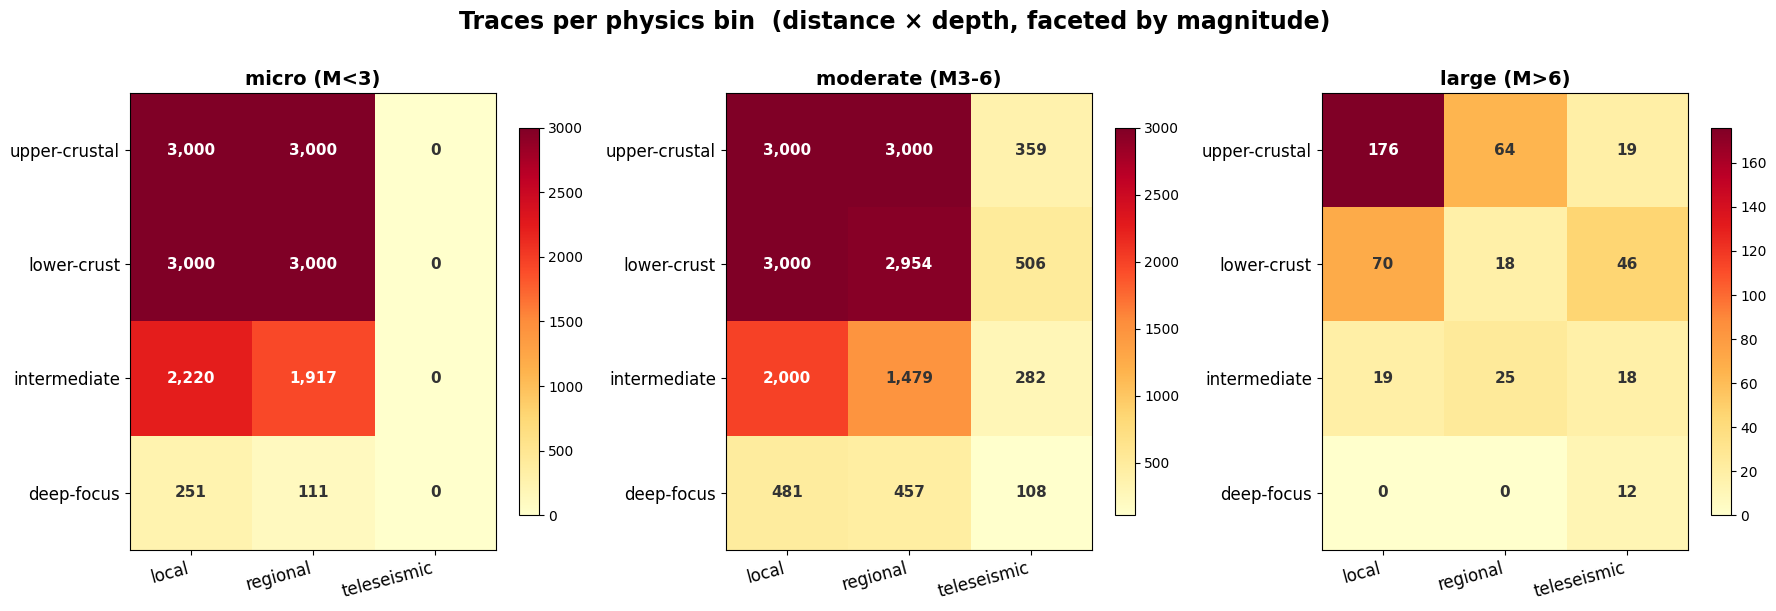

Saved → bin_heatmap.png


In [56]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Traces per physics bin  (distance × depth, faceted by magnitude)',
             fontsize=17, fontweight='bold', y=1.01)

short_dist  = [d.split(' ')[0] for d in DIST_LABELS]    # 'local', 'regional', 'teleseismic'
short_depth = [d.split(' ')[0] for d in DEPTH_LABELS]   # 'upper-crustal', 'lower-crust', ...

for ax, mag_label in zip(axes, MAG_LABELS):
    matrix = np.zeros((len(DEPTH_LABELS), len(DIST_LABELS)))
    for i, dl in enumerate(DEPTH_LABELS):
        for j, dist in enumerate(DIST_LABELS):
            matrix[i, j] = ((benchmark['mag_bin'] == mag_label) &
                             (benchmark['depth_bin'] == dl) &
                             (benchmark['dist_bin']  == dist)).sum()

    im = ax.imshow(matrix, aspect='auto', cmap='YlOrRd')
    ax.set_title(mag_label, fontsize=14, fontweight='bold', pad=6)
    ax.set_xticks(range(len(DIST_LABELS)))
    ax.set_xticklabels(short_dist, fontsize=12, rotation=15, ha='right')
    ax.set_yticks(range(len(DEPTH_LABELS)))
    ax.set_yticklabels(short_depth, fontsize=12)
    plt.colorbar(im, ax=ax, shrink=0.85)

    for i in range(len(DEPTH_LABELS)):
        for j in range(len(DIST_LABELS)):
            val = int(matrix[i, j])
            ax.text(j, i, f'{val:,}', ha='center', va='center',
                    fontsize=11, fontweight='bold',
                    color='white' if val > matrix.max() * 0.55 else '#333333')

plt.tight_layout()
plt.savefig('bin_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → bin_heatmap.png')


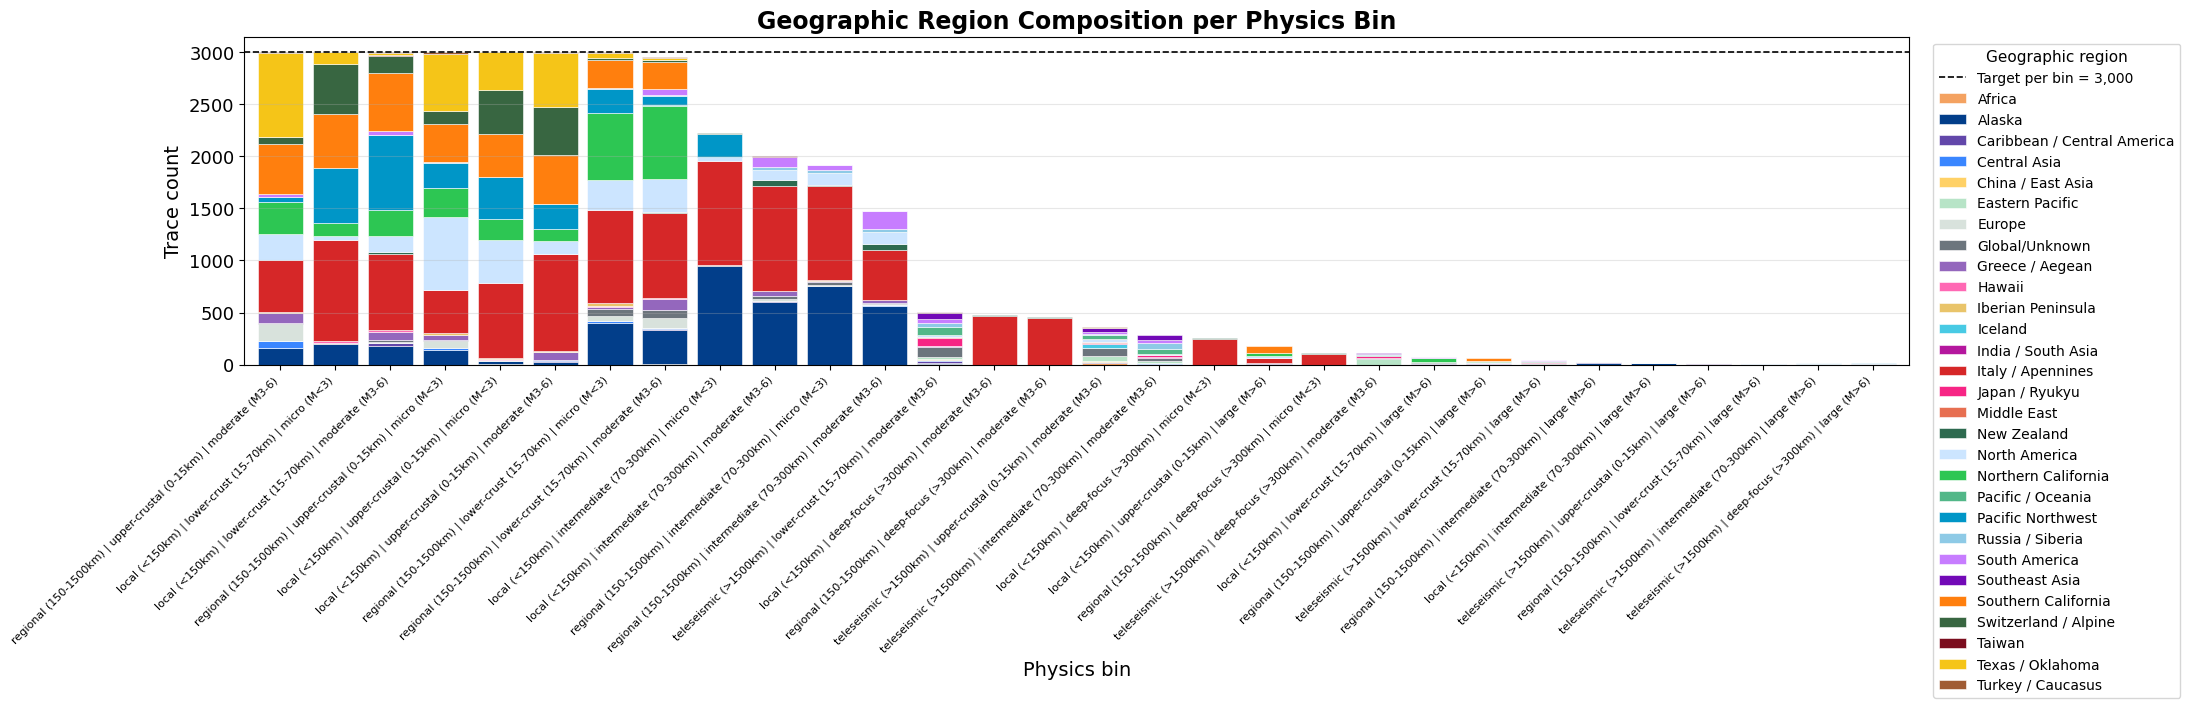

Saved → bin_composition.png


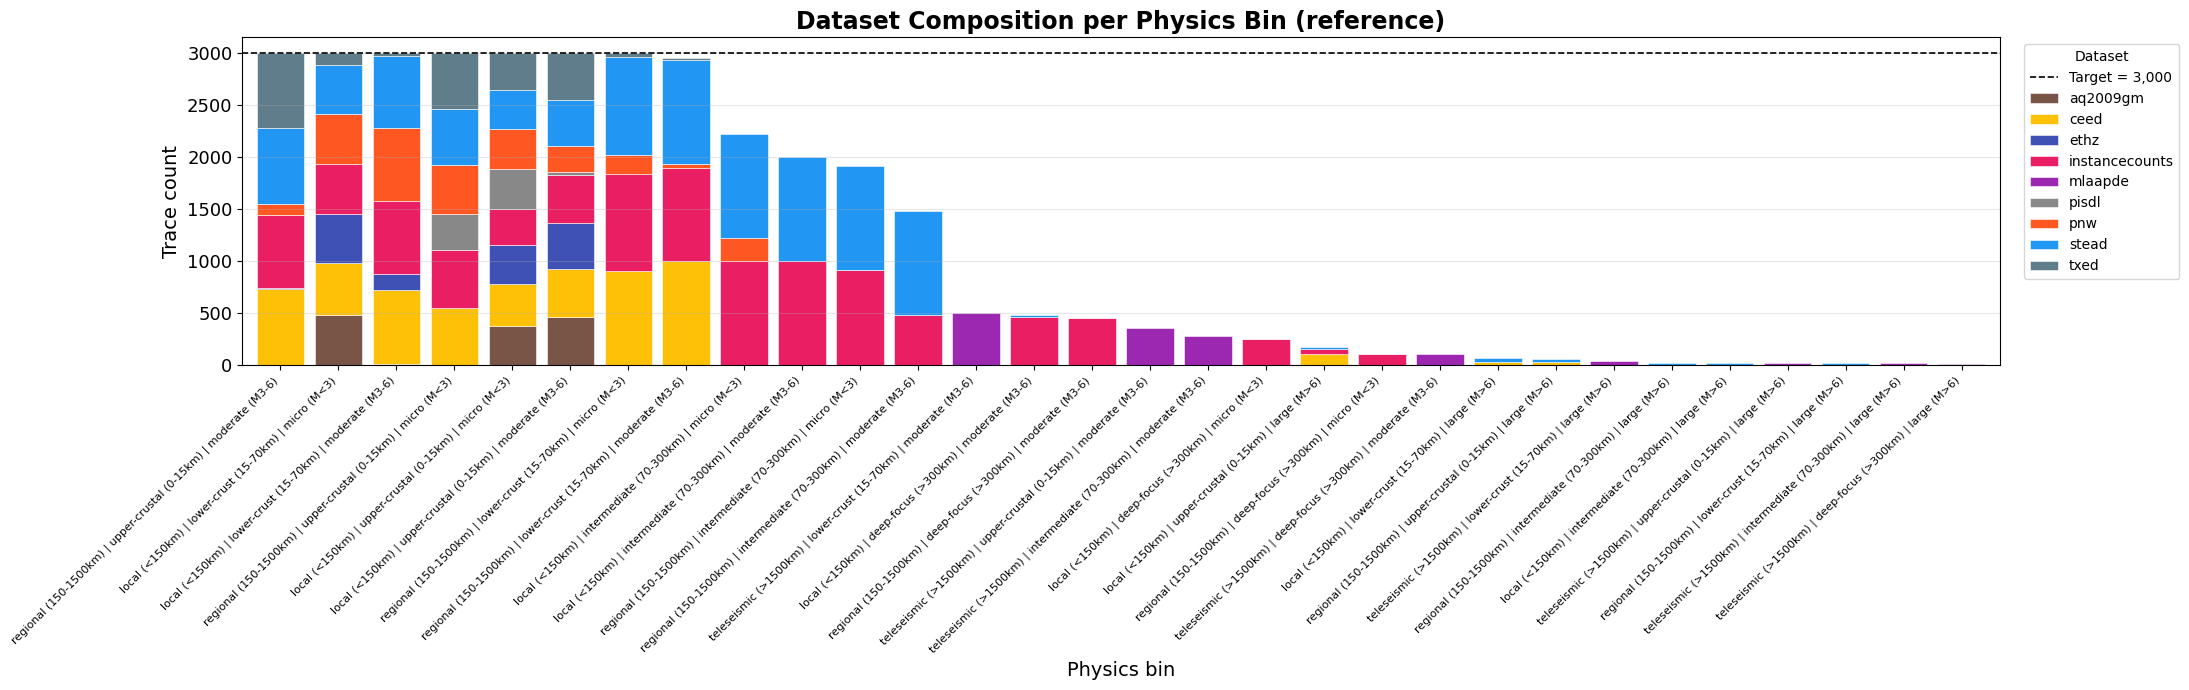

Saved → bin_composition_by_dataset.png


In [57]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Only fully-binned traces (excludes flat-sample specialty datasets)
binned = benchmark[
    benchmark['physics_bin'].notna() &
    ~benchmark['physics_bin'].isin(['partial', 'OBS_flat', 'volcanic_flat',
                                     'strong_motion_flat', 'unusable'])
].copy()

# ── Visually distinct colors — 8 most common regions use full-saturation hues;
#    rarer regions use distinct but lower-weight tones.
REGION_COLORS = {
    # North America — blue family, well-separated within group
    'Alaska':                   '#023e8a',   # deep navy
    'Pacific Northwest':        '#0096c7',   # ocean blue
    'Northern California':      '#2dc653',   # vivid green
    'Southern California':      '#ff7f0e',   # strong orange
    'Texas / Oklahoma':         '#f5c518',   # gold-yellow
    'Hawaii':                   '#ff69b4',   # hot pink (rare, should be visible)
    'North America':            '#cce5ff',   # pale blue  (generic catchall)
    # Caribbean / South America
    'Caribbean / Central America': '#6247aa', # violet
    'South America':            '#c77dff',   # lavender
    # Europe — warm/cool greens, clearly distinct from North America blues
    'Switzerland / Alpine':     '#386641',   # forest green
    'Italy / Apennines':        '#d62728',   # strong red  (most common EU region)
    'Greece / Aegean':          '#9467bd',   # purple
    'Turkey / Caucasus':        '#a05c34',   # saddle brown
    'Iberian Peninsula':        '#e9c46a',   # sand yellow
    'Iceland':                  '#48cae4',   # glacier blue
    'Europe':                   '#d8e2dc',   # pale sage   (generic catchall)
    # Africa / Middle East
    'Africa':                   '#f4a261',   # terracotta
    'Middle East':              '#e76f51',   # burnt sienna
    # Asia — reds, pinks, purples (distinct from European reds)
    'Taiwan':                   '#7b0d1e',   # dark maroon
    'Japan / Ryukyu':           '#f72585',   # neon magenta
    'Southeast Asia':           '#7209b7',   # deep purple
    'India / South Asia':       '#b5179e',   # violet-magenta
    'Central Asia':             '#3a86ff',   # cobalt blue
    'China / East Asia':        '#ffd166',   # butter yellow
    'Russia / Siberia':         '#8ecae6',   # steel blue
    # Pacific
    'New Zealand':              '#2d6a4f',   # dark teal
    'Pacific / Oceania':        '#52b788',   # sea green
    'Eastern Pacific':          '#b7e4c7',   # mint (rare)
    # Fallbacks
    'Global/Unknown':           '#6c757d',   # slate gray
    'Unknown':                  '#ced4da',   # light gray
}

# Count by (physics_bin, geo_region)
counts = (
    binned.groupby(['physics_bin', 'geo_region'])
    .size()
    .unstack(fill_value=0)
)
counts = counts.loc[counts.sum(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(22, 7))
counts.plot(
    kind='bar', stacked=True, ax=ax,
    color=[REGION_COLORS.get(r, '#888888') for r in counts.columns],
    width=0.82, edgecolor='white', linewidth=0.4,
)
ax.set_xlabel('Physics bin', fontsize=14)
ax.set_ylabel('Trace count', fontsize=14)
ax.set_title('Geographic Region Composition per Physics Bin', fontsize=17, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
ax.tick_params(axis='y', labelsize=13)
ax.axhline(y=TARGET_PER_BIN, color='black', linestyle='--',
           linewidth=1.2, label=f'Target per bin = {TARGET_PER_BIN:,}')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=10,
          title='Geographic region', title_fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.set_facecolor('white')

plt.tight_layout()
plt.savefig('bin_composition.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → bin_composition.png')

# ── Reference: same chart by dataset ─────────────────────────────────────────
DS_COLORS_REF = {
    'mlaapde': '#9C27B0', 'instancecounts': '#E91E63', 'stead': '#2196F3',
    'obst2024': '#009688', 'pnw': '#FF5722', 'ceed': '#FFC107',
    'aq2009gm': '#795548', 'txed': '#607D8B', 'ethz': '#3F51B5',
    'vcseis': '#8BC34A', 'cwa': '#FF4081',
}
counts_ds = (
    binned.groupby(['physics_bin', 'dataset'])
    .size().unstack(fill_value=0)
)
counts_ds = counts_ds.loc[counts_ds.sum(axis=1).sort_values(ascending=False).index]

fig2, ax2 = plt.subplots(figsize=(22, 7))
counts_ds.plot(
    kind='bar', stacked=True, ax=ax2,
    color=[DS_COLORS_REF.get(d, '#888888') for d in counts_ds.columns],
    width=0.82, edgecolor='white', linewidth=0.4,
)
ax2.set_xlabel('Physics bin', fontsize=14)
ax2.set_ylabel('Trace count', fontsize=14)
ax2.set_title('Dataset Composition per Physics Bin (reference)', fontsize=17, fontweight='bold')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right', fontsize=8)
ax2.tick_params(axis='y', labelsize=13)
ax2.axhline(y=TARGET_PER_BIN, color='black', linestyle='--', linewidth=1.2,
            label=f'Target = {TARGET_PER_BIN:,}')
ax2.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=10, title='Dataset')
ax2.grid(axis='y', alpha=0.3)
ax2.set_facecolor('white')
plt.tight_layout()
plt.savefig('bin_composition_by_dataset.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → bin_composition_by_dataset.png')


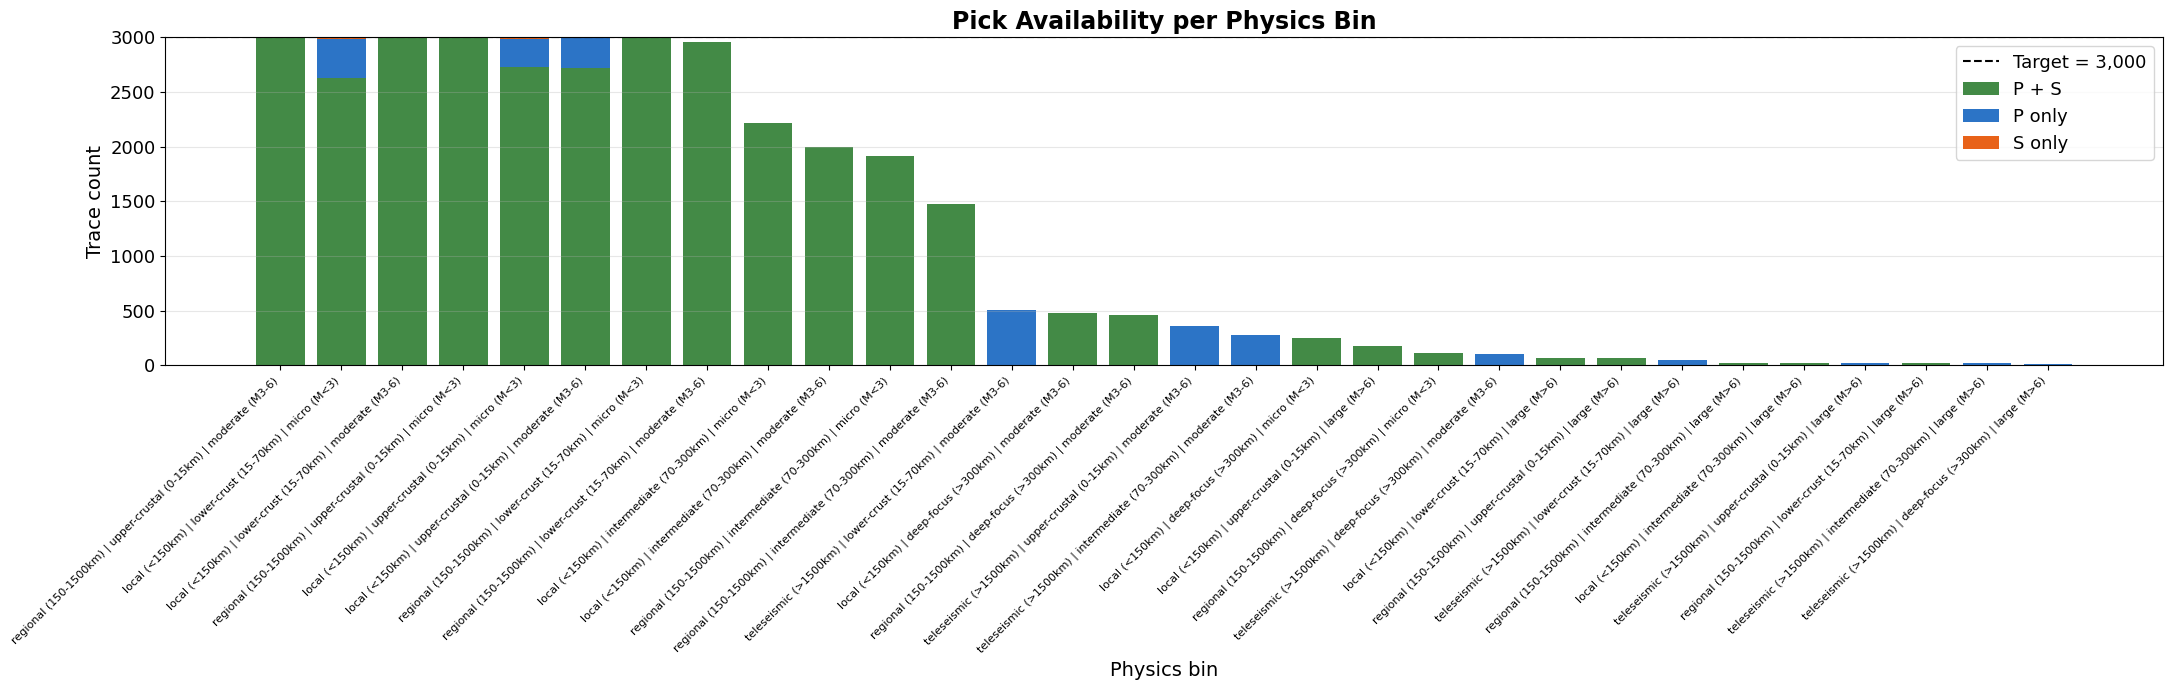

Saved → bin_pick_availability.png


In [58]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

binned = benchmark[
    benchmark['physics_bin'].notna() &
    ~benchmark['physics_bin'].isin(['partial', 'OBS_flat', 'volcanic_flat',
                                     'strong_motion_flat', 'unusable'])
].copy()

binned['pick_type'] = np.where(
    binned['has_p_pick'] & binned['has_s_pick'], 'P + S',
    np.where(binned['has_p_pick'],               'P only',
    np.where(binned['has_s_pick'],               'S only', 'neither'))
)

counts = (
    binned.groupby(['physics_bin', 'pick_type'])
    .size().unstack(fill_value=0)
    .reindex(columns=['P + S', 'P only', 'S only'], fill_value=0)
)
counts = counts.loc[counts.sum(axis=1).sort_values(ascending=False).index]

bins = counts.index.tolist()
x    = np.arange(len(bins))

fig, ax = plt.subplots(figsize=(22, 7))
ax.bar(x, counts['P + S'],  label='P + S',  color='#2e7d32', alpha=0.9)
ax.bar(x, counts['P only'], label='P only', color='#1565c0', alpha=0.9,
       bottom=counts['P + S'])
ax.bar(x, counts['S only'], label='S only', color='#e65100', alpha=0.9,
       bottom=counts['P + S'] + counts['P only'])
ax.axhline(y=TARGET_PER_BIN, color='black', linestyle='--',
           linewidth=1.5, label=f'Target = {TARGET_PER_BIN:,}')

ax.set_xticks(x)
ax.set_xticklabels(bins, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Trace count', fontsize=14)
ax.set_xlabel('Physics bin', fontsize=14)
ax.set_title('Pick Availability per Physics Bin', fontsize=17, fontweight='bold')
ax.tick_params(axis='y', labelsize=13)
ax.legend(fontsize=13)
ax.grid(axis='y', alpha=0.3)
ax.set_facecolor('white')

plt.tight_layout()
plt.savefig('bin_pick_availability.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → bin_pick_availability.png')


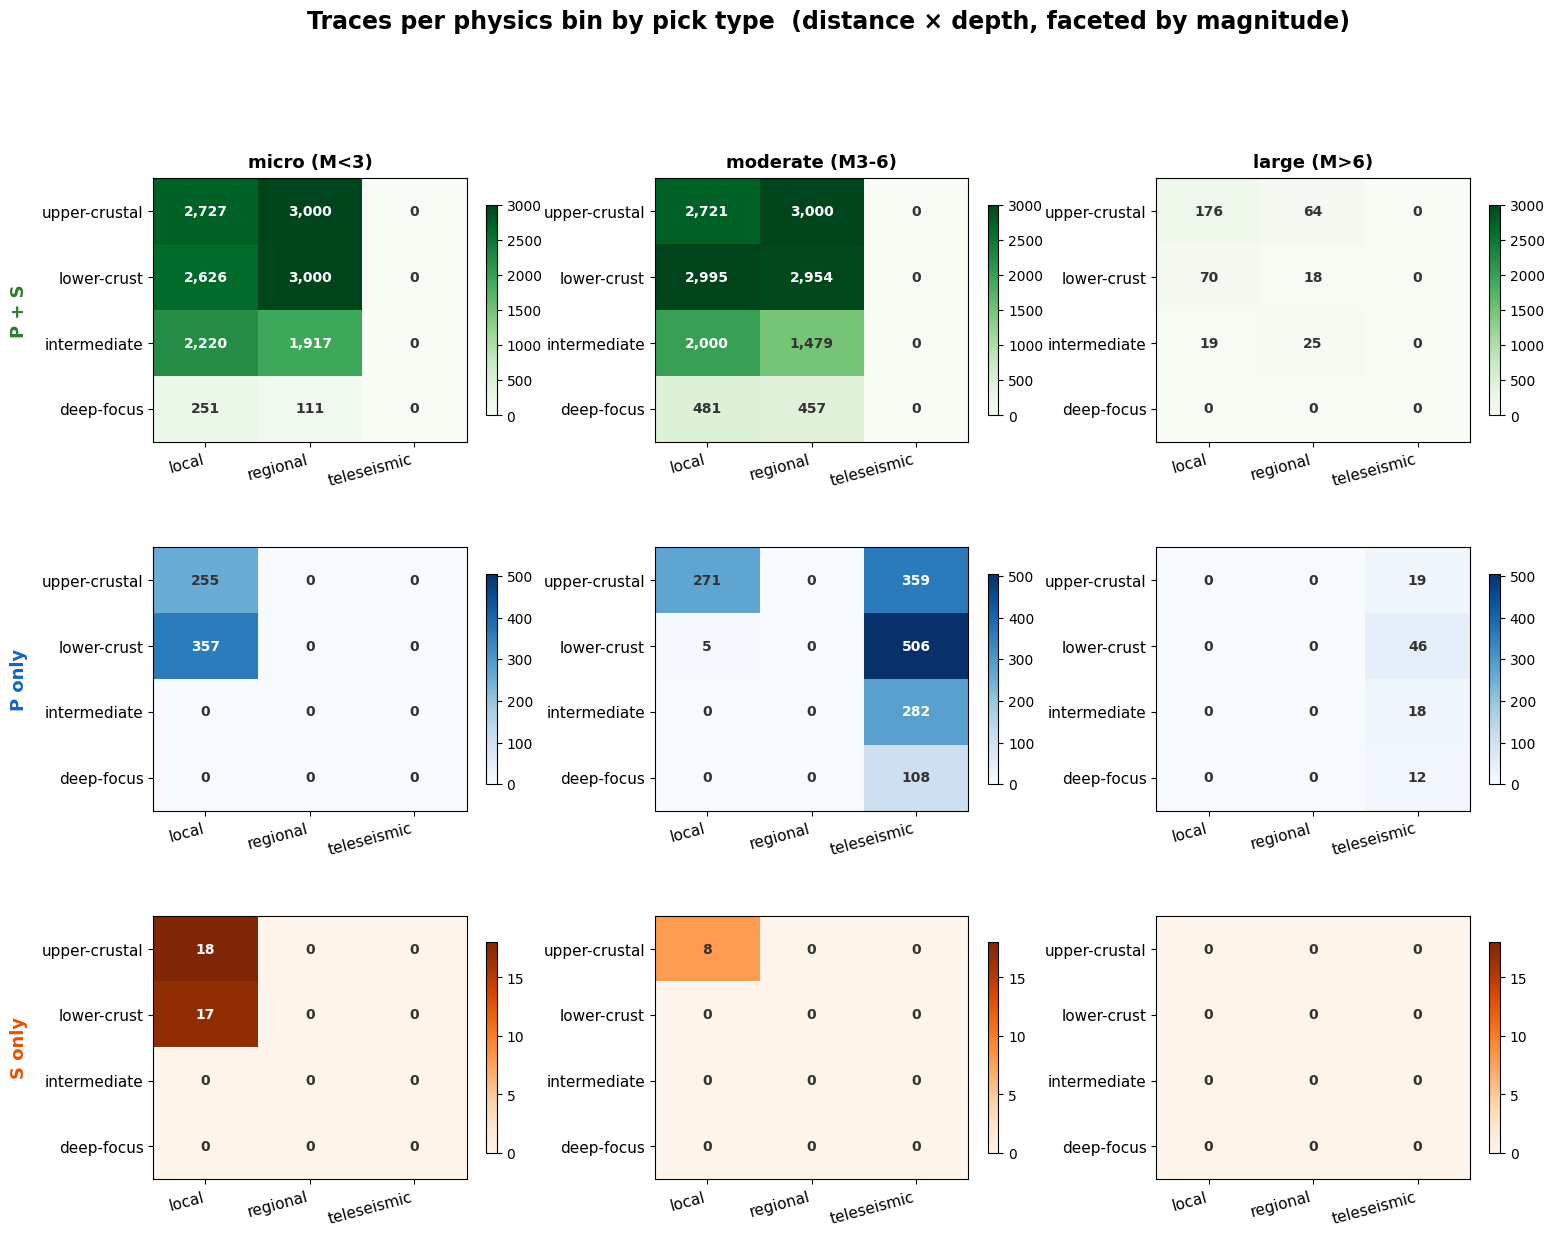

Saved → bin_pick_types.png


In [59]:
import matplotlib.pyplot as plt
import numpy as np

PICK_TYPES = {
    'P + S':  lambda b: b['has_p_pick'] & b['has_s_pick'],
    'P only': lambda b: b['has_p_pick'] & ~b['has_s_pick'],
    'S only': lambda b: ~b['has_p_pick'] & b['has_s_pick'],
}
PICK_CMAPS  = {'P + S': 'Greens', 'P only': 'Blues', 'S only': 'Oranges'}
PICK_COLORS = {'P + S': '#2e7d32', 'P only': '#1565c0', 'S only': '#e65100'}

binned = benchmark[
    benchmark['physics_bin'].notna() &
    ~benchmark['physics_bin'].isin(['partial', 'OBS_flat', 'volcanic_flat',
                                     'strong_motion_flat', 'unusable'])
].copy()

short_dist  = [d.split(' ')[0] for d in DIST_LABELS]
short_depth = [d.split(' ')[0] for d in DEPTH_LABELS]

fig, axes = plt.subplots(
    len(PICK_TYPES), len(MAG_LABELS),
    figsize=(18, 13),
    gridspec_kw={'hspace': 0.40, 'wspace': 0.28},
)
fig.suptitle('Traces per physics bin by pick type  (distance × depth, faceted by magnitude)',
             fontsize=17, fontweight='bold', y=1.01)

for row_idx, (pick_label, pick_filter) in enumerate(PICK_TYPES.items()):
    subset  = binned[pick_filter(binned)]
    row_max = max(
        (int(((subset[subset['mag_bin'] == ml]['dist_bin'] == dl) &
               (subset[subset['mag_bin'] == ml]['depth_bin'] == dpl)).sum())
         for ml in MAG_LABELS for dpl in DEPTH_LABELS for dl in DIST_LABELS),
        default=1,
    )
    row_max = max(row_max, 1)

    for col_idx, mag_label in enumerate(MAG_LABELS):
        ax      = axes[row_idx, col_idx]
        mag_sub = subset[subset['mag_bin'] == mag_label]

        matrix = np.zeros((len(DEPTH_LABELS), len(DIST_LABELS)))
        for i, dpl in enumerate(DEPTH_LABELS):
            for j, dl in enumerate(DIST_LABELS):
                matrix[i, j] = int(((mag_sub['dist_bin'] == dl) &
                                     (mag_sub['depth_bin'] == dpl)).sum())

        im = ax.imshow(matrix, aspect='auto',
                       cmap=PICK_CMAPS[pick_label], vmin=0, vmax=row_max)
        plt.colorbar(im, ax=ax, shrink=0.80)

        for i in range(len(DEPTH_LABELS)):
            for j in range(len(DIST_LABELS)):
                val = int(matrix[i, j])
                ax.text(j, i, f'{val:,}', ha='center', va='center',
                        fontsize=10, fontweight='bold',
                        color='white' if val > row_max * 0.55 else '#333333')

        ax.set_xticks(range(len(DIST_LABELS)))
        ax.set_yticks(range(len(DEPTH_LABELS)))
        ax.set_xticklabels(short_dist,  fontsize=11, rotation=15, ha='right')
        ax.set_yticklabels(short_depth, fontsize=11)

        if row_idx == 0:
            ax.set_title(mag_label, fontsize=13, fontweight='bold', pad=8)
        if col_idx == 0:
            ax.set_ylabel(pick_label, fontsize=13, fontweight='bold',
                          labelpad=10, color=PICK_COLORS[pick_label])

plt.savefig('bin_pick_types.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → bin_pick_types.png')


/tmp/ipykernel_2244411/4030933195.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ds_stats['ps']     = benchmark.groupby('dataset').apply(
/tmp/ipykernel_2244411/4030933195.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ds_stats['p_only'] = benchmark.groupby('dataset').apply(
/tmp/ipykernel_2244411/4030933195.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is de

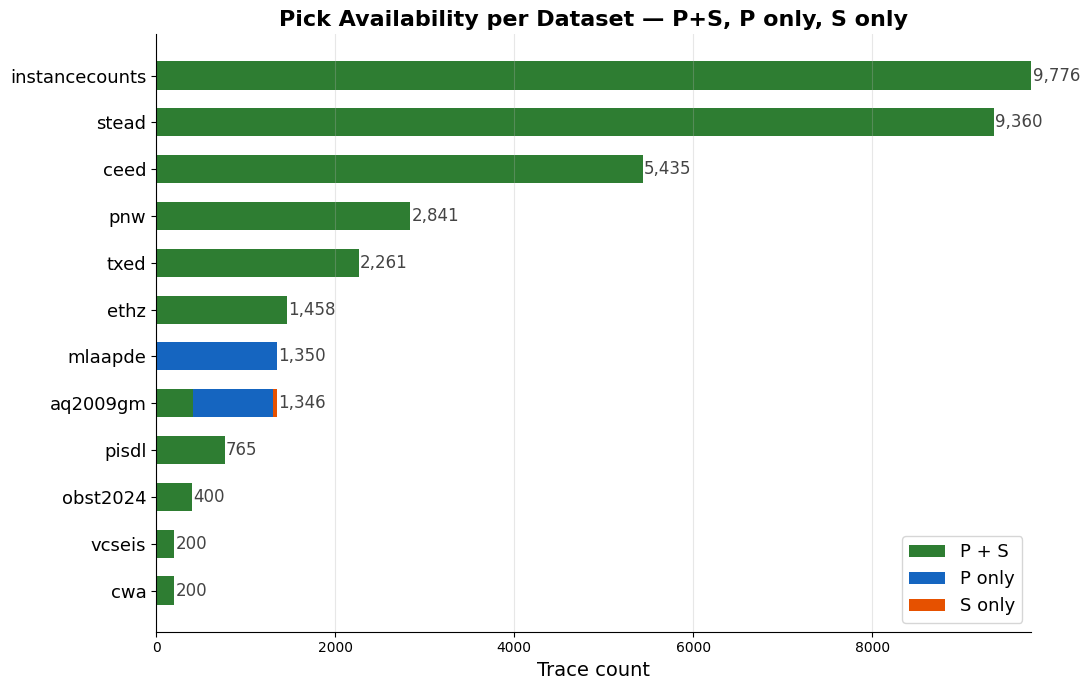

Saved → pick_availability_per_dataset.png


In [60]:
import matplotlib.pyplot as plt
import numpy as np

ds_stats = benchmark.groupby('dataset').agg(
    total = ('has_p_pick', 'count'),
    n_p   = ('has_p_pick', 'sum'),
    n_s   = ('has_s_pick', 'sum'),
).reset_index()

ds_stats['ps']     = benchmark.groupby('dataset').apply(
    lambda g: (g['has_p_pick'] & g['has_s_pick']).sum()).values
ds_stats['p_only'] = benchmark.groupby('dataset').apply(
    lambda g: (g['has_p_pick'] & ~g['has_s_pick']).sum()).values
ds_stats['s_only'] = benchmark.groupby('dataset').apply(
    lambda g: (~g['has_p_pick'] & g['has_s_pick']).sum()).values
ds_stats = ds_stats.sort_values('total', ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(11, 7))
y = np.arange(len(ds_stats))
ax.barh(y, ds_stats['ps'],     color='#2e7d32', label='P + S',  height=0.6)
ax.barh(y, ds_stats['p_only'], color='#1565c0', label='P only', height=0.6,
        left=ds_stats['ps'])
ax.barh(y, ds_stats['s_only'], color='#e65100', label='S only', height=0.6,
        left=ds_stats['ps'] + ds_stats['p_only'])

for i, row in ds_stats.iterrows():
    ax.text(row['total'] + 15, i, f"{row['total']:,}", va='center',
            fontsize=12, color='#444')

ax.set_yticks(y)
ax.set_yticklabels(ds_stats['dataset'], fontsize=13)
ax.set_xlabel('Trace count', fontsize=14)
ax.set_title('Pick Availability per Dataset — P+S, P only, S only',
             fontsize=16, fontweight='bold')
ax.legend(fontsize=13)
ax.grid(axis='x', alpha=0.3)
ax.set_facecolor('white')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('pick_availability_per_dataset.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → pick_availability_per_dataset.png')
